### POC ML for Futures Trading


In [1]:
# Load API key from .env file
from dotenv import load_dotenv
import os

load_dotenv()  # Load environment variables from .env file
api_key = os.environ.get('POLYGON_API_KEY')

if api_key:
    print(f"API key loaded successfully (length: {len(api_key)} chars)")
else:
    print("POLYGON_API_KEY not found in .env file!")
    print("Create a .env file in the trading_brains folder with:")
    print("POLYGON_API_KEY=your-api-key-here")

API key loaded successfully (length: 32 chars)


In [ ]:
# =============================================================================
# BLOCK 1: Data Import from Polygon.io — 1-Minute Stock Data
# =============================================================================
import requests
import pandas as pd
from datetime import datetime, timedelta
import time
import os

# Load API key from environment
api_key = os.getenv("POLYGON_API_KEY")


def fetch_polygon_1min_data(symbol: str, start_date: str, end_date: str, api_key: str) -> pd.DataFrame:
    """
    Fetch 1-minute OHLCV data from Polygon.io

    Args:
        symbol: Stock ticker symbol (e.g., 'SPY', 'QQQ', 'IWM')
        start_date: Start date in 'YYYY-MM-DD' format
        end_date: End date in 'YYYY-MM-DD' format
        api_key: Polygon.io API key

    Returns:
        DataFrame with DatetimeIndex (UTC), columns: open, high, low, close, volume, vwap
    """
    all_data = []
    multiplier = 1
    timespan = "minute"

    url = f"https://api.polygon.io/v2/aggs/ticker/{symbol}/range/{multiplier}/{timespan}/{start_date}/{end_date}"

    params = {
        "adjusted": "true",
        "sort": "asc",
        "limit": 50000,
        "apiKey": api_key,
    }

    print(f"Fetching {symbol} data from {start_date} to {end_date}...")

    page = 0
    while url:
        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f"❌ Error: {response.status_code} - {response.text}")
            break

        data = response.json()

        if data.get("results"):
            all_data.extend(data["results"])
            page += 1
            print(f"  Page {page}: {len(data['results'])} bars (total: {len(all_data):,})")

        # Handle pagination
        url = data.get("next_url")
        if url:
            params = {"apiKey": api_key}
            time.sleep(0.15)  # Rate limiting for free tier

    if not all_data:
        print("❌ No data received")
        return pd.DataFrame()

    # Convert to DataFrame
    df = pd.DataFrame(all_data)

    # Rename columns to standard lowercase format
    df = df.rename(columns={
        "t": "timestamp",
        "o": "open",
        "h": "high",
        "l": "low",
        "c": "close",
        "v": "volume",
        "vw": "vwap",
        "n": "num_trades",
    })

    # Convert timestamp from milliseconds to datetime (UTC)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp")

    # Convert to US/Eastern for session-based features later
    df.index = df.index.tz_convert("US/Eastern")

    # Keep only regular trading hours (09:30–16:00 ET)
    df = df.between_time("09:30", "15:59")

    # Select relevant columns
    cols = ["open", "high", "low", "close", "volume"]
    if "vwap" in df.columns:
        cols.append("vwap")

    df = df[cols]

    print(f"\n✅ Loaded {len(df):,} 1-minute bars for {symbol}")
    print(f"   Date range: {df.index.min()} to {df.index.max()}")
    print(f"   Trading days: {df.index.normalize().nunique()}")
    print(f"   Timezone: {df.index.tz}")

    return df


# -----------------------------------------------------------------------------
# Fetch SPY (S&P 500 ETF) — adjust dates as needed
# Polygon free tier: 2 years of historical data
# -----------------------------------------------------------------------------
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=180)).strftime("%Y-%m-%d")

df = fetch_polygon_1min_data("SPY", start_date, end_date, api_key)

# Optional: save raw data so you don't re-fetch every run
# df.to_csv(f"SPY_{start_date}_to_{end_date}_raw.csv")
# df = pd.read_csv("SPY_..._raw.csv", index_col="timestamp", parse_dates=True)

Fetching SPY data from 2025-03-10 to 2026-03-05...
  Fetched 50000 bars (total: 50000)
  Fetched 50000 bars (total: 100000)
  Fetched 50000 bars (total: 150000)
  Fetched 50000 bars (total: 200000)
  Fetched 14587 bars (total: 214587)
✅ Loaded 214587 1-minute bars for SPY
   Date range: 2025-03-10 08:00:00 to 2026-03-05 00:59:00


In [4]:
df.head()

,open,high,low,close,volume,vwap
timestamp,,,,,,
2025-03-10 08:00:00,572.70,573.06,572.70,573.06,3096.0,572.9685
2025-03-10 08:01:00,573.17,573.24,573.17,573.23,689.0,573.1959
2025-03-10 08:03:00,572.67,572.67,572.56,572.56,559.0,572.6817
2025-03-10 08:04:00,572.23,572.23,572.23,572.23,479.0,572.3074
2025-03-10 08:05:00,572.13,572.13,571.88,571.88,1187.0,571.9919


# Feature Engineering

- Creation of common metrics for time-series
- RSI, MACD, Bollinger Mavg, ATR, Stochastic-K, Return 1, Return 5, Rolling Average 30, 60, 90, 120, Volatility

In [ ]:
# =============================================================================
# BLOCK 2: Data Preparation — Validate and inspect
# =============================================================================
# Column names stay lowercase: open, high, low, close, volume, vwap
# This matches Polygon's native output and all downstream feature blocks.
# =============================================================================

print("=" * 60)
print("DATA VALIDATION")
print("=" * 60)

# --- Basic shape & range ---
print(f"\n📊 DataFrame shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Date range: {df.index.min()} → {df.index.max()}")
print(f"📆 Trading days: {df.index.normalize().nunique()}")
print(f"🕐 Frequency: 1-minute bars")
print(f"📋 Columns: {list(df.columns)}")

# --- Missing values ---
missing = df.isnull().sum()
if missing.sum() == 0:
    print("\n✅ No missing values")
else:
    print(f"\n⚠️  Missing values:")
    print(missing[missing > 0])

# --- Zero-volume bars (can distort volume-based features) ---
zero_vol = (df["volume"] == 0).sum()
if zero_vol > 0:
    print(f"\n⚠️  {zero_vol:,} bars with zero volume ({zero_vol / len(df) * 100:.2f}%)")
    print("   Consider: these can distort VWAP, Volume_Ratio, OBV etc.")
else:
    print(f"\n✅ No zero-volume bars")

# --- Bars per day sanity check (expect ~390 for full session) ---
bars_per_day = df.groupby(df.index.date).size()
print(f"\n📈 Bars per trading day:")
print(f"   Mean:  {bars_per_day.mean():.0f}")
print(f"   Min:   {bars_per_day.min()} ({bars_per_day.idxmin()})")
print(f"   Max:   {bars_per_day.max()} ({bars_per_day.idxmax()})")

if bars_per_day.min() < 300:
    short_days = bars_per_day[bars_per_day < 300]
    print(f"   ⚠️  {len(short_days)} short days (<300 bars) — likely half-days or holidays:")
    for d, count in short_days.items():
        print(f"      {d}: {count} bars")

# --- Price sanity ---
print(f"\n💰 Price range: ${df['close'].min():.2f} – ${df['close'].max():.2f}")
print(f"   Mean spread (high-low): ${(df['high'] - df['low']).mean():.4f}")

# --- Quick peek ---
print(f"\n📊 Sample data (last 5 rows):")
print(df.tail())

DATA SUMMARY

📊 DataFrame shape: (214587, 6)
📅 Date range: 2025-03-10 08:00:00 to 2026-03-05 00:59:00
🕐 Frequency: 1-minute bars

📋 Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Vwap']

🔍 Missing values per column:
Open      0
High      0
Low       0
Close     0
Volume    0
Vwap      0
dtype: int64


In [6]:
df.head(20)

,Open,High,Low,Close,Volume,Vwap
timestamp,,,,,,
2025-03-10 08:00:00,572.70,573.06,572.70,573.06,3096.0,572.9685
2025-03-10 08:01:00,573.17,573.24,573.17,573.23,689.0,573.1959
2025-03-10 08:03:00,572.67,572.67,572.56,572.56,559.0,572.6817
2025-03-10 08:04:00,572.23,572.23,572.23,572.23,479.0,572.3074
2025-03-10 08:05:00,572.13,572.13,571.88,571.88,1187.0,571.9919
2025-03-10 08:06:00,572.01,572.09,572.01,572.09,738.0,572.0592
2025-03-10 08:07:00,572.31,572.40,572.19,572.19,1013.0,572.3199
2025-03-10 08:09:00,571.77,571.77,571.77,571.77,171.0,571.7975
2025-03-10 08:10:00,571.84,571.89,571.84,571.89,3640.0,571.8696


In [ ]:
# =============================================================================
# BLOCK 3: Feature Engineering — Technical Indicators + Trading-Notes Features
# =============================================================================
# Assumes df has: DatetimeIndex (US/Eastern), columns: open, high, low, close, volume, vwap
# All column names lowercase throughout.
# =============================================================================

import numpy as np
from datetime import time as dt_time

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────

def calculate_rsi(prices: pd.Series, period: int = 14) -> pd.Series:
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist

def calculate_bollinger_bands(prices: pd.Series, period: int = 20, std_dev: float = 2.0):
    middle = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper = middle + (std * std_dev)
    lower = middle - (std * std_dev)
    return middle, upper, lower

def calculate_atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    tr1 = high - low
    tr2 = abs(high - close.shift())
    tr3 = abs(low - close.shift())
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

def calculate_stochastic(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    lowest_low = low.rolling(window=period).min()
    highest_high = high.rolling(window=period).max()
    return 100 * (close - lowest_low) / (highest_high - lowest_low + 1e-10)

# ─────────────────────────────────────────────────────────────
# HELPER COLUMNS (used by multiple sections, cleaned up at end)
# ─────────────────────────────────────────────────────────────
df["_date"] = df.index.date
df["_time"] = df.index.time
df["_week"] = df.index.isocalendar().week.astype(int)
df["_year"] = df.index.year
df["_year_week"] = df["_year"].astype(str) + "_" + df["_week"].astype(str).str.zfill(2)
df["_hour_group"] = df.index.strftime("%Y-%m-%d_%H")


# =============================================================================
# SECTION A: Original V1 Indicators
# =============================================================================
print("\n📊 Section A: Core technical indicators...")

# OHLC Standard Deviation (intraday bar volatility)
df["OHLC_Std"] = df[["open", "high", "low", "close"]].std(axis=1)

# RSI
df["RSI"] = calculate_rsi(df["close"], period=14)

# MACD
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = calculate_macd(df["close"])

# Bollinger Bands
df["BB_Middle"], df["BB_Upper"], df["BB_Lower"] = calculate_bollinger_bands(df["close"], period=20)

# ATR
df["ATR"] = calculate_atr(df["high"], df["low"], df["close"], period=14)

# Stochastic Oscillator
df["Stochastic_K"] = calculate_stochastic(df["high"], df["low"], df["close"], period=14)

# Returns
df["Return_1"] = df["close"].pct_change(1)
df["Return_5"] = df["close"].pct_change(5)

# Simple Moving Averages
df["SMA_30"] = df["close"].rolling(window=30).mean()
df["SMA_60"] = df["close"].rolling(window=60).mean()
df["SMA_120"] = df["close"].rolling(window=120).mean()
df["SMA_390"] = df["close"].rolling(window=390).mean()

# Volatility
df["Volatility_20"] = df["Return_1"].rolling(window=20).std()

# Volume features
df["Volume_SMA_20"] = df["volume"].rolling(window=20).mean()
df["Volume_Ratio"] = df["volume"] / df["Volume_SMA_20"]

# Price position within bar's range
df["Price_Position"] = (df["close"] - df["low"]) / (df["high"] - df["low"] + 1e-10)


# =============================================================================
# SECTION B: Daily Open & Previous-Day Levels
#   Igor, George, Mike: "dOpen, pdEQ, pdHigh & pdLow"
# =============================================================================
print("📊 Section B: Daily open & previous-day levels...")

daily_agg = df.groupby("_date").agg(
    dOpen=("open", "first"),
    dHigh=("high", "max"),
    dLow=("low", "min"),
    dClose=("close", "last"),
)
daily_agg["pdHigh"] = daily_agg["dHigh"].shift(1)
daily_agg["pdLow"] = daily_agg["dLow"].shift(1)
daily_agg["pdClose"] = daily_agg["dClose"].shift(1)
daily_agg["pdEQ"] = (daily_agg["pdHigh"] + daily_agg["pdLow"]) / 2

df = df.merge(
    daily_agg[["dOpen", "pdHigh", "pdLow", "pdClose", "pdEQ"]],
    left_on="_date", right_index=True, how="left",
)

df["dist_dOpen"] = df["close"] - df["dOpen"]
df["dist_pdHigh"] = df["close"] - df["pdHigh"]
df["dist_pdLow"] = df["close"] - df["pdLow"]
df["dist_pdEQ"] = df["close"] - df["pdEQ"]


# =============================================================================
# SECTION C: Bollinger Band Width (squeeze detection)
#   Notes: "tightening range, declining volume = recipe for a big move"
# =============================================================================
print("📊 Section C: Bollinger Band width...")

df["BB_Width"] = (df["BB_Upper"] - df["BB_Lower"]) / df["BB_Middle"]


# =============================================================================
# SECTION D: Previous-Day & Previous-Week vWAP Close
#   Whensailing: "pdvWAP always gives a nice reaction on first touch"
#   Trader R: "weekly vWAP closes — you get the best reactions off of these"
# =============================================================================
print("📊 Section D: Previous vWAP closes...")

if "vwap" in df.columns:
    # Previous day vWAP close
    daily_vwap_close = df.groupby("_date")["vwap"].last().rename("pdvWAP")
    daily_vwap_close = daily_vwap_close.shift(1)
    df = df.merge(daily_vwap_close, left_on="_date", right_index=True, how="left")
    df["dist_pdvWAP"] = df["close"] - df["pdvWAP"]

    # Previous week vWAP close
    weekly_vwap_close = df.groupby("_year_week")["vwap"].last().rename("pwvWAP")
    weekly_vwap_close = weekly_vwap_close.shift(1)
    df = df.merge(weekly_vwap_close, left_on="_year_week", right_index=True, how="left")
    df["dist_pwvWAP"] = df["close"] - df["pwvWAP"]
else:
    print("   ⚠️  No vwap column — skipping vWAP features")


# =============================================================================
# SECTION E: Initial Balance (first 60 minutes)
#   Dukie: "mark the high and low of the first candle of the day on the 1-hourly"
# =============================================================================
print("📊 Section E: Initial Balance...")

ib_mask = (df["_time"] >= dt_time(9, 30)) & (df["_time"] < dt_time(10, 30))
ib_data = df[ib_mask].groupby("_date").agg(
    IB_High=("high", "max"),
    IB_Low=("low", "min"),
)
ib_data["IB_Range"] = ib_data["IB_High"] - ib_data["IB_Low"]

df = df.merge(ib_data, left_on="_date", right_index=True, how="left")

df["above_IB"] = (df["close"] > df["IB_High"]).astype(int)
df["below_IB"] = (df["close"] < df["IB_Low"]).astype(int)


# =============================================================================
# SECTION F: Anchored VWAPs (from daily & weekly highs/lows)
#   Daniel: anchored vWAPs are "so underrated"
# =============================================================================
print("📊 Section F: Anchored VWAPs...")

def anchored_vwap_from_extreme(df, groupby_col, extreme="high"):
    """Compute VWAP anchored from the bar where the daily/weekly high or low was made."""
    result = pd.Series(np.nan, index=df.index, dtype=float)

    for name, group in df.groupby(groupby_col):
        if len(group) < 2:
            continue
        anchor_idx = group["high"].idxmax() if extreme == "high" else group["low"].idxmin()
        after = group.loc[anchor_idx:]
        if len(after) < 1:
            continue
        tp = (after["high"] + after["low"] + after["close"]) / 3
        cum_vol = after["volume"].cumsum()
        cum_tp_vol = (tp * after["volume"]).cumsum()
        avwap = cum_tp_vol / cum_vol.replace(0, np.nan)
        result.loc[avwap.index] = avwap.values

    return result

df["aVWAP_daily_high"] = anchored_vwap_from_extreme(df, "_date", "high")
df["aVWAP_daily_low"] = anchored_vwap_from_extreme(df, "_date", "low")
df["aVWAP_weekly_high"] = anchored_vwap_from_extreme(df, "_year_week", "high")
df["aVWAP_weekly_low"] = anchored_vwap_from_extreme(df, "_year_week", "low")

df["dist_aVWAP_daily_high"] = df["close"] - df["aVWAP_daily_high"]
df["dist_aVWAP_daily_low"] = df["close"] - df["aVWAP_daily_low"]
df["dist_aVWAP_weekly_high"] = df["close"] - df["aVWAP_weekly_high"]
df["dist_aVWAP_weekly_low"] = df["close"] - df["aVWAP_weekly_low"]


# =============================================================================
# SECTION G: Naked POCs (hourly, daily, weekly)
#   George: "nPOCs on first touch (very strong)"
# =============================================================================
print("📊 Section G: Naked POCs (this may take a moment)...")

def compute_poc(group, num_bins=50):
    """Find the price level with highest volume in a group."""
    if len(group) < 2 or group["volume"].sum() == 0:
        return np.nan
    prices = group["close"]
    pmin, pmax = prices.min(), prices.max()
    if pmin == pmax:
        return pmin
    bins = np.linspace(pmin, pmax, num_bins + 1)
    bin_idx = np.clip(np.digitize(prices.values, bins) - 1, 0, num_bins - 1)
    vol_per_bin = np.zeros(num_bins)
    for i, v in zip(bin_idx, group["volume"].values):
        vol_per_bin[i] += v
    best = np.argmax(vol_per_bin)
    return (bins[best] + bins[best + 1]) / 2


def build_npoc_features(df, groupby_col, prefix, lookback=10):
    """Track naked (untapped) POCs from completed periods."""
    poc_series = df.groupby(groupby_col).apply(compute_poc).rename("poc")

    result_above = pd.Series(np.nan, index=df.index, dtype=float)
    result_below = pd.Series(np.nan, index=df.index, dtype=float)

    group_to_bars = df.groupby(groupby_col)
    period_data = []
    for g in poc_series.index:
        poc_val = poc_series[g]
        if pd.isna(poc_val):
            continue
        g_bars = group_to_bars.get_group(g)
        period_data.append({
            "poc": poc_val,
            "end_ts": g_bars.index[-1],
            "tapped": False,
        })

    active = []
    pidx = 0

    for ts, row in df.iterrows():
        hi, lo, price = row["high"], row["low"], row["close"]

        # Add completed-period POCs
        while pidx < len(period_data) and period_data[pidx]["end_ts"] < ts:
            active.append(period_data[pidx])
            pidx += 1

        # Mark tapped, keep only naked
        still_naked = []
        for n in active[-(lookback * 2):]:
            if lo <= n["poc"] <= hi:
                n["tapped"] = True
            if not n["tapped"]:
                still_naked.append(n)
        active = still_naked[-lookback:]

        above = [n["poc"] for n in active if n["poc"] > price]
        below = [n["poc"] for n in active if n["poc"] <= price]
        if above:
            result_above.at[ts] = min(above)
        if below:
            result_below.at[ts] = max(below)

    df[f"nPOC_{prefix}_above"] = result_above
    df[f"nPOC_{prefix}_below"] = result_below
    df[f"dist_nPOC_{prefix}_above"] = result_above - df["close"]
    df[f"dist_nPOC_{prefix}_below"] = df["close"] - result_below
    return df

df = build_npoc_features(df, "_hour_group", "hourly", lookback=10)
df = build_npoc_features(df, "_date", "daily", lookback=10)
df = build_npoc_features(df, "_year_week", "weekly", lookback=5)


# =============================================================================
# SECTION H: Untapped Period Closes (hourly, daily, weekly)
#   Whensailing: "untapped daily EQ: the longer it remains untapped, the better"
#   Dukie: "wickless Dailys usually get revisited and cleaned up"
# =============================================================================
print("📊 Section H: Untapped closes...")

def build_untapped_closes(df, groupby_col, prefix, lookback=10):
    """Track period close prices that haven't been revisited yet."""
    period_closes = df.groupby(groupby_col)["close"].last()

    result_above = pd.Series(np.nan, index=df.index, dtype=float)
    result_below = pd.Series(np.nan, index=df.index, dtype=float)

    group_to_bars = df.groupby(groupby_col)
    period_data = []
    for g in period_closes.index:
        val = period_closes[g]
        if pd.isna(val):
            continue
        g_bars = group_to_bars.get_group(g)
        period_data.append({"close": val, "end_ts": g_bars.index[-1], "tapped": False})

    active = []
    pidx = 0

    for ts, row in df.iterrows():
        hi, lo, price = row["high"], row["low"], row["close"]

        while pidx < len(period_data) and period_data[pidx]["end_ts"] < ts:
            active.append(period_data[pidx])
            pidx += 1

        still = []
        for item in active[-(lookback * 2):]:
            if lo <= item["close"] <= hi:
                item["tapped"] = True
            if not item["tapped"]:
                still.append(item)
        active = still[-lookback:]

        above = [a["close"] for a in active if a["close"] > price]
        below = [a["close"] for a in active if a["close"] <= price]
        if above:
            result_above.at[ts] = min(above)
        if below:
            result_below.at[ts] = max(below)

    df[f"untapped_close_{prefix}_above"] = result_above
    df[f"untapped_close_{prefix}_below"] = result_below
    df[f"dist_untapped_{prefix}_above"] = result_above - df["close"]
    df[f"dist_untapped_{prefix}_below"] = df["close"] - result_below
    return df

df = build_untapped_closes(df, "_hour_group", "hourly", lookback=10)
df = build_untapped_closes(df, "_date", "daily", lookback=10)
df = build_untapped_closes(df, "_year_week", "weekly", lookback=5)


# =============================================================================
# SECTION I: Candle Body & Wick Analysis
#   Igor: "closing of a candle bar near the open = lack of conviction"
#   IMI: "candles with no wick = high probability it's going to be retested"
# =============================================================================
print("📊 Section I: Candle structure...")

candle_range = df["high"] - df["low"] + 1e-10
df["candle_body_ratio"] = abs(df["close"] - df["open"]) / candle_range
df["upper_wick_ratio"] = (df["high"] - df[["open", "close"]].max(axis=1)) / candle_range
df["lower_wick_ratio"] = (df[["open", "close"]].min(axis=1) - df["low"]) / candle_range
df["candle_direction"] = np.sign(df["close"] - df["open"])


# =============================================================================
# SECTION J: Value Areas (daily & weekly — VAH, VAL, POC)
#   George, Mike, Patrick: core concept throughout notes
# =============================================================================
print("📊 Section J: Value Areas...")

def compute_value_area(group, num_bins=100, va_pct=0.70):
    """Compute POC, VAH, VAL using volume-at-price distribution."""
    if len(group) < 2 or group["volume"].sum() == 0:
        return pd.Series({"VA_POC": np.nan, "VAH": np.nan, "VAL": np.nan})

    price_min, price_max = group["low"].min(), group["high"].max()
    if price_min == price_max:
        return pd.Series({"VA_POC": price_min, "VAH": price_min, "VAL": price_min})

    bins = np.linspace(price_min, price_max, num_bins + 1)
    bin_mids = (bins[:-1] + bins[1:]) / 2
    bin_width = bins[1] - bins[0]

    vol_per_bin = np.zeros(num_bins)
    for _, row in group.iterrows():
        lo_idx = max(0, int((row["low"] - price_min) / bin_width))
        hi_idx = min(num_bins - 1, int((row["high"] - price_min) / bin_width))
        bar_bins = hi_idx - lo_idx + 1
        if bar_bins > 0:
            share = row["volume"] / bar_bins
            for b in range(lo_idx, hi_idx + 1):
                vol_per_bin[b] += share

    total_vol = vol_per_bin.sum()
    if total_vol == 0:
        return pd.Series({"VA_POC": np.nan, "VAH": np.nan, "VAL": np.nan})

    poc_bin = np.argmax(vol_per_bin)
    va_vol = vol_per_bin[poc_bin]
    lo_bound, hi_bound = poc_bin, poc_bin

    while va_vol / total_vol < va_pct:
        look_down = vol_per_bin[lo_bound - 1] if lo_bound > 0 else 0
        look_up = vol_per_bin[hi_bound + 1] if hi_bound < num_bins - 1 else 0
        if look_down == 0 and look_up == 0:
            break
        if look_up >= look_down and hi_bound < num_bins - 1:
            hi_bound += 1
            va_vol += vol_per_bin[hi_bound]
        elif lo_bound > 0:
            lo_bound -= 1
            va_vol += vol_per_bin[lo_bound]
        else:
            hi_bound += 1
            va_vol += vol_per_bin[hi_bound]

    return pd.Series({"VA_POC": bin_mids[poc_bin], "VAH": bin_mids[hi_bound], "VAL": bin_mids[lo_bound]})

# Daily value areas
daily_va = df.groupby("_date").apply(compute_value_area).reset_index()
daily_va.columns = ["_date", "dVA_POC", "dVAH", "dVAL"]
daily_va["pdVA_POC"] = daily_va["dVA_POC"].shift(1)
daily_va["pdVAH"] = daily_va["dVAH"].shift(1)
daily_va["pdVAL"] = daily_va["dVAL"].shift(1)
df = df.merge(daily_va, on="_date", how="left")

df["dist_pdVAH"] = df["close"] - df["pdVAH"]
df["dist_pdVAL"] = df["close"] - df["pdVAL"]
df["dist_pdVA_POC"] = df["close"] - df["pdVA_POC"]

# Weekly value areas
weekly_va = df.groupby("_year_week").apply(compute_value_area).reset_index()
weekly_va.columns = ["_year_week", "wVA_POC", "wVAH", "wVAL"]
weekly_va["pwVA_POC"] = weekly_va["wVA_POC"].shift(1)
weekly_va["pwVAH"] = weekly_va["wVAH"].shift(1)
weekly_va["pwVAL"] = weekly_va["wVAL"].shift(1)
df = df.merge(weekly_va, on="_year_week", how="left")

df["dist_pwVAH"] = df["close"] - df["pwVAH"]
df["dist_pwVAL"] = df["close"] - df["pwVAL"]


# =============================================================================
# SECTION K: OBV (On-Balance Volume)
#   Notes: "always use OBV — volume leads price"
# =============================================================================
print("📊 Section K: OBV...")

df["OBV"] = (np.sign(df["close"].diff()) * df["volume"]).fillna(0).cumsum()
df["OBV_slope_30"] = df["OBV"].rolling(30).apply(
    lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) == 30 else np.nan,
    raw=False,
)


# =============================================================================
# SECTION L: Session / Time-of-Day Features
#   Igor Sessions, Victor: "first hour of NY session"
#   Patrick: variable "time" helped him become profitable
# =============================================================================
print("📊 Section L: Session features...")

df["minutes_since_open"] = ((df.index.hour * 60 + df.index.minute) - (9 * 60 + 30)).clip(lower=0)
df["day_of_week"] = df.index.dayofweek

df["is_first_30min"] = (df["_time"] < dt_time(10, 0)).astype(int)
df["is_last_30min"] = (df["_time"] >= dt_time(15, 30)).astype(int)
df["is_lunch"] = ((df["_time"] >= dt_time(12, 0)) & (df["_time"] < dt_time(13, 30))).astype(int)


# =============================================================================
# SECTION M: Engulfing Candles
#   IMI: "a large engulfing candle gives a bearish bias — works on every TF"
# =============================================================================
print("📊 Section M: Engulfing candles...")

prev_open = df["open"].shift(1)
prev_close = df["close"].shift(1)
prev_body = abs(prev_close - prev_open)
curr_body = abs(df["close"] - df["open"])

df["bullish_engulfing"] = (
    (df["close"] > df["open"])
    & (prev_close < prev_open)
    & (df["open"] <= prev_close)
    & (df["close"] >= prev_open)
    & (curr_body > prev_body)
).astype(int)

df["bearish_engulfing"] = (
    (df["close"] < df["open"])
    & (prev_close > prev_open)
    & (df["open"] >= prev_close)
    & (df["close"] <= prev_open)
    & (curr_body > prev_body)
).astype(int)


# =============================================================================
# SECTION N: Garman-Klass Volatility
#   Better intraday volatility estimator using full OHLC
# =============================================================================
print("📊 Section N: Garman-Klass volatility...")

log_hl = np.log(df["high"] / df["low"]) ** 2
log_co = np.log(df["close"] / df["open"]) ** 2
gk_bar = 0.5 * log_hl - (2 * np.log(2) - 1) * log_co
df["GK_volatility_30"] = gk_bar.rolling(30).mean().apply(np.sqrt)


# =============================================================================
# SECTION O: RSI & Indicator Rate-of-Change
#   Captures momentum acceleration/deceleration for the model
# =============================================================================
print("📊 Section O: Indicator momentum...")

df["RSI_change_5"] = df["RSI"] - df["RSI"].shift(5)
df["RSI_change_15"] = df["RSI"] - df["RSI"].shift(15)
df["MACD_Hist_change_5"] = df["MACD_Hist"] - df["MACD_Hist"].shift(5)
df["BB_Width_change_5"] = df["BB_Width"] - df["BB_Width"].shift(5)
df["BB_Width_change_15"] = df["BB_Width"] - df["BB_Width"].shift(15)
df["OBV_change_5"] = df["OBV"] - df["OBV"].shift(5)
df["OBV_change_15"] = df["OBV"] - df["OBV"].shift(15)

# Volume spike flags
df["volume_spike_lag_1"] = (df["Volume_Ratio"].shift(1) > 2.0).astype(int)
df["volume_spike_lag_5"] = (df["Volume_Ratio"].shift(5) > 2.0).astype(int)

# Price relative to SMAs (trend position)
df["price_vs_SMA_30"] = df["close"] / df["SMA_30"] - 1
df["price_vs_SMA_60"] = df["close"] / df["SMA_60"] - 1


# =============================================================================
# CLEANUP: Remove helper columns
# =============================================================================
helper_cols = ["_date", "_time", "_week", "_year", "_year_week", "_hour_group"]
df.drop(columns=[c for c in helper_cols if c in df.columns], inplace=True, errors="ignore")


# =============================================================================
# SUMMARY
# =============================================================================
base_cols = {"open", "high", "low", "close", "volume", "vwap"}
new_cols = [c for c in df.columns if c not in base_cols]

print(f"\n{'=' * 60}")
print(f"✅ Feature engineering complete!")
print(f"{'=' * 60}")
print(f"📊 DataFrame shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📋 New features: {len(new_cols)}")
print(f"\n🔍 Missing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

FEATURE ENGINEERING

✅ Feature engineering complete!

📊 DataFrame shape: (214587, 26)

📋 New columns added:
  - OHLC_Std
  - RSI
  - MACD
  - MACD_Signal
  - MACD_Hist
  - BB_Middle
  - BB_Upper
  - BB_Lower
  - ATR
  - Stochastic_K
  - Return_1
  - Return_5
  - SMA_30
  - SMA_60
  - SMA_120
  - SMA_390
  - Volatility_20
  - Volume_SMA_20
  - Volume_Ratio
  - Price_Position

🔍 Missing values (from rolling calculations):
Return_1            1
Return_5            5
SMA_30             29
SMA_60             59
SMA_120           119
SMA_390           389
Volatility_20      20
Volume_SMA_20      19
Volume_Ratio       19
Price_Position      0
dtype: int64


In [ ]:
# =============================================================================
# BLOCK 3: Feature Engineering — Technical Indicators + Trading-Notes Features
# =============================================================================
# Assumes df has: DatetimeIndex (US/Eastern), columns: open, high, low, close, volume, vwap
# All column names lowercase throughout.
# =============================================================================

import numpy as np
from datetime import time as dt_time

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────

def calculate_rsi(prices: pd.Series, period: int = 14) -> pd.Series:
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist

def calculate_bollinger_bands(prices: pd.Series, period: int = 20, std_dev: float = 2.0):
    middle = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper = middle + (std * std_dev)
    lower = middle - (std * std_dev)
    return middle, upper, lower

def calculate_atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    tr1 = high - low
    tr2 = abs(high - close.shift())
    tr3 = abs(low - close.shift())
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

def calculate_stochastic(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    lowest_low = low.rolling(window=period).min()
    highest_high = high.rolling(window=period).max()
    return 100 * (close - lowest_low) / (highest_high - lowest_low + 1e-10)

# ─────────────────────────────────────────────────────────────
# HELPER COLUMNS (used by multiple sections, cleaned up at end)
# ─────────────────────────────────────────────────────────────
df["_date"] = df.index.date
df["_time"] = df.index.time
df["_week"] = df.index.isocalendar().week.astype(int)
df["_year"] = df.index.year
df["_year_week"] = df["_year"].astype(str) + "_" + df["_week"].astype(str).str.zfill(2)
df["_hour_group"] = df.index.strftime("%Y-%m-%d_%H")


# =============================================================================
# SECTION A: Original V1 Indicators
# =============================================================================
print("\n📊 Section A: Core technical indicators...")

# OHLC Standard Deviation (intraday bar volatility)
df["OHLC_Std"] = df[["open", "high", "low", "close"]].std(axis=1)

# RSI
df["RSI"] = calculate_rsi(df["close"], period=14)

# MACD
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = calculate_macd(df["close"])

# Bollinger Bands
df["BB_Middle"], df["BB_Upper"], df["BB_Lower"] = calculate_bollinger_bands(df["close"], period=20)

# ATR
df["ATR"] = calculate_atr(df["high"], df["low"], df["close"], period=14)

# Stochastic Oscillator
df["Stochastic_K"] = calculate_stochastic(df["high"], df["low"], df["close"], period=14)

# Returns
df["Return_1"] = df["close"].pct_change(1)
df["Return_5"] = df["close"].pct_change(5)

# Simple Moving Averages
df["SMA_30"] = df["close"].rolling(window=30).mean()
df["SMA_60"] = df["close"].rolling(window=60).mean()
df["SMA_120"] = df["close"].rolling(window=120).mean()
df["SMA_390"] = df["close"].rolling(window=390).mean()

# Volatility
df["Volatility_20"] = df["Return_1"].rolling(window=20).std()

# Volume features
df["Volume_SMA_20"] = df["volume"].rolling(window=20).mean()
df["Volume_Ratio"] = df["volume"] / df["Volume_SMA_20"]

# Price position within bar's range
df["Price_Position"] = (df["close"] - df["low"]) / (df["high"] - df["low"] + 1e-10)


# =============================================================================
# SECTION B: Daily Open & Previous-Day Levels
#   Igor, George, Mike: "dOpen, pdEQ, pdHigh & pdLow"
# =============================================================================
print("📊 Section B: Daily open & previous-day levels...")

daily_agg = df.groupby("_date").agg(
    dOpen=("open", "first"),
    dHigh=("high", "max"),
    dLow=("low", "min"),
    dClose=("close", "last"),
)
daily_agg["pdHigh"] = daily_agg["dHigh"].shift(1)
daily_agg["pdLow"] = daily_agg["dLow"].shift(1)
daily_agg["pdClose"] = daily_agg["dClose"].shift(1)
daily_agg["pdEQ"] = (daily_agg["pdHigh"] + daily_agg["pdLow"]) / 2

df = df.merge(
    daily_agg[["dOpen", "pdHigh", "pdLow", "pdClose", "pdEQ"]],
    left_on="_date", right_index=True, how="left",
)

df["dist_dOpen"] = df["close"] - df["dOpen"]
df["dist_pdHigh"] = df["close"] - df["pdHigh"]
df["dist_pdLow"] = df["close"] - df["pdLow"]
df["dist_pdEQ"] = df["close"] - df["pdEQ"]


# =============================================================================
# SECTION C: Bollinger Band Width (squeeze detection)
#   Notes: "tightening range, declining volume = recipe for a big move"
# =============================================================================
print("📊 Section C: Bollinger Band width...")

df["BB_Width"] = (df["BB_Upper"] - df["BB_Lower"]) / df["BB_Middle"]


# =============================================================================
# SECTION D: Previous-Day & Previous-Week vWAP Close
#   Whensailing: "pdvWAP always gives a nice reaction on first touch"
#   Trader R: "weekly vWAP closes — you get the best reactions off of these"
# =============================================================================
print("📊 Section D: Previous vWAP closes...")

if "vwap" in df.columns:
    # Previous day vWAP close
    daily_vwap_close = df.groupby("_date")["vwap"].last().rename("pdvWAP")
    daily_vwap_close = daily_vwap_close.shift(1)
    df = df.merge(daily_vwap_close, left_on="_date", right_index=True, how="left")
    df["dist_pdvWAP"] = df["close"] - df["pdvWAP"]

    # Previous week vWAP close
    weekly_vwap_close = df.groupby("_year_week")["vwap"].last().rename("pwvWAP")
    weekly_vwap_close = weekly_vwap_close.shift(1)
    df = df.merge(weekly_vwap_close, left_on="_year_week", right_index=True, how="left")
    df["dist_pwvWAP"] = df["close"] - df["pwvWAP"]
else:
    print("   ⚠️  No vwap column — skipping vWAP features")


# =============================================================================
# SECTION E: Initial Balance (first 60 minutes)
#   Dukie: "mark the high and low of the first candle of the day on the 1-hourly"
# =============================================================================
print("📊 Section E: Initial Balance...")

ib_mask = (df["_time"] >= dt_time(9, 30)) & (df["_time"] < dt_time(10, 30))
ib_data = df[ib_mask].groupby("_date").agg(
    IB_High=("high", "max"),
    IB_Low=("low", "min"),
)
ib_data["IB_Range"] = ib_data["IB_High"] - ib_data["IB_Low"]

df = df.merge(ib_data, left_on="_date", right_index=True, how="left")

df["above_IB"] = (df["close"] > df["IB_High"]).astype(int)
df["below_IB"] = (df["close"] < df["IB_Low"]).astype(int)


# =============================================================================
# SECTION F: Anchored VWAPs (from daily & weekly highs/lows)
#   Daniel: anchored vWAPs are "so underrated"
# =============================================================================
print("📊 Section F: Anchored VWAPs...")

def anchored_vwap_from_extreme(df, groupby_col, extreme="high"):
    """Compute VWAP anchored from the bar where the daily/weekly high or low was made."""
    result = pd.Series(np.nan, index=df.index, dtype=float)

    for name, group in df.groupby(groupby_col):
        if len(group) < 2:
            continue
        anchor_idx = group["high"].idxmax() if extreme == "high" else group["low"].idxmin()
        after = group.loc[anchor_idx:]
        if len(after) < 1:
            continue
        tp = (after["high"] + after["low"] + after["close"]) / 3
        cum_vol = after["volume"].cumsum()
        cum_tp_vol = (tp * after["volume"]).cumsum()
        avwap = cum_tp_vol / cum_vol.replace(0, np.nan)
        result.loc[avwap.index] = avwap.values

    return result

df["aVWAP_daily_high"] = anchored_vwap_from_extreme(df, "_date", "high")
df["aVWAP_daily_low"] = anchored_vwap_from_extreme(df, "_date", "low")
df["aVWAP_weekly_high"] = anchored_vwap_from_extreme(df, "_year_week", "high")
df["aVWAP_weekly_low"] = anchored_vwap_from_extreme(df, "_year_week", "low")

df["dist_aVWAP_daily_high"] = df["close"] - df["aVWAP_daily_high"]
df["dist_aVWAP_daily_low"] = df["close"] - df["aVWAP_daily_low"]
df["dist_aVWAP_weekly_high"] = df["close"] - df["aVWAP_weekly_high"]
df["dist_aVWAP_weekly_low"] = df["close"] - df["aVWAP_weekly_low"]


# =============================================================================
# SECTION G: Naked POCs (hourly, daily, weekly)
#   George: "nPOCs on first touch (very strong)"
# =============================================================================
print("📊 Section G: Naked POCs (this may take a moment)...")

def compute_poc(group, num_bins=50):
    """Find the price level with highest volume in a group."""
    if len(group) < 2 or group["volume"].sum() == 0:
        return np.nan
    prices = group["close"]
    pmin, pmax = prices.min(), prices.max()
    if pmin == pmax:
        return pmin
    bins = np.linspace(pmin, pmax, num_bins + 1)
    bin_idx = np.clip(np.digitize(prices.values, bins) - 1, 0, num_bins - 1)
    vol_per_bin = np.zeros(num_bins)
    for i, v in zip(bin_idx, group["volume"].values):
        vol_per_bin[i] += v
    best = np.argmax(vol_per_bin)
    return (bins[best] + bins[best + 1]) / 2


def build_npoc_features(df, groupby_col, prefix, lookback=10):
    """Track naked (untapped) POCs from completed periods."""
    poc_series = df.groupby(groupby_col).apply(compute_poc).rename("poc")

    result_above = pd.Series(np.nan, index=df.index, dtype=float)
    result_below = pd.Series(np.nan, index=df.index, dtype=float)

    group_to_bars = df.groupby(groupby_col)
    period_data = []
    for g in poc_series.index:
        poc_val = poc_series[g]
        if pd.isna(poc_val):
            continue
        g_bars = group_to_bars.get_group(g)
        period_data.append({
            "poc": poc_val,
            "end_ts": g_bars.index[-1],
            "tapped": False,
        })

    active = []
    pidx = 0

    for ts, row in df.iterrows():
        hi, lo, price = row["high"], row["low"], row["close"]

        # Add completed-period POCs
        while pidx < len(period_data) and period_data[pidx]["end_ts"] < ts:
            active.append(period_data[pidx])
            pidx += 1

        # Mark tapped, keep only naked
        still_naked = []
        for n in active[-(lookback * 2):]:
            if lo <= n["poc"] <= hi:
                n["tapped"] = True
            if not n["tapped"]:
                still_naked.append(n)
        active = still_naked[-lookback:]

        above = [n["poc"] for n in active if n["poc"] > price]
        below = [n["poc"] for n in active if n["poc"] <= price]
        if above:
            result_above.at[ts] = min(above)
        if below:
            result_below.at[ts] = max(below)

    df[f"nPOC_{prefix}_above"] = result_above
    df[f"nPOC_{prefix}_below"] = result_below
    df[f"dist_nPOC_{prefix}_above"] = result_above - df["close"]
    df[f"dist_nPOC_{prefix}_below"] = df["close"] - result_below
    return df

df = build_npoc_features(df, "_hour_group", "hourly", lookback=10)
df = build_npoc_features(df, "_date", "daily", lookback=10)
df = build_npoc_features(df, "_year_week", "weekly", lookback=5)


# =============================================================================
# SECTION H: Untapped Period Closes (hourly, daily, weekly)
#   Whensailing: "untapped daily EQ: the longer it remains untapped, the better"
#   Dukie: "wickless Dailys usually get revisited and cleaned up"
# =============================================================================
print("📊 Section H: Untapped closes...")

def build_untapped_closes(df, groupby_col, prefix, lookback=10):
    """Track period close prices that haven't been revisited yet."""
    period_closes = df.groupby(groupby_col)["close"].last()

    result_above = pd.Series(np.nan, index=df.index, dtype=float)
    result_below = pd.Series(np.nan, index=df.index, dtype=float)

    group_to_bars = df.groupby(groupby_col)
    period_data = []
    for g in period_closes.index:
        val = period_closes[g]
        if pd.isna(val):
            continue
        g_bars = group_to_bars.get_group(g)
        period_data.append({"close": val, "end_ts": g_bars.index[-1], "tapped": False})

    active = []
    pidx = 0

    for ts, row in df.iterrows():
        hi, lo, price = row["high"], row["low"], row["close"]

        while pidx < len(period_data) and period_data[pidx]["end_ts"] < ts:
            active.append(period_data[pidx])
            pidx += 1

        still = []
        for item in active[-(lookback * 2):]:
            if lo <= item["close"] <= hi:
                item["tapped"] = True
            if not item["tapped"]:
                still.append(item)
        active = still[-lookback:]

        above = [a["close"] for a in active if a["close"] > price]
        below = [a["close"] for a in active if a["close"] <= price]
        if above:
            result_above.at[ts] = min(above)
        if below:
            result_below.at[ts] = max(below)

    df[f"untapped_close_{prefix}_above"] = result_above
    df[f"untapped_close_{prefix}_below"] = result_below
    df[f"dist_untapped_{prefix}_above"] = result_above - df["close"]
    df[f"dist_untapped_{prefix}_below"] = df["close"] - result_below
    return df

df = build_untapped_closes(df, "_hour_group", "hourly", lookback=10)
df = build_untapped_closes(df, "_date", "daily", lookback=10)
df = build_untapped_closes(df, "_year_week", "weekly", lookback=5)


# =============================================================================
# SECTION I: Candle Body & Wick Analysis
#   Igor: "closing of a candle bar near the open = lack of conviction"
#   IMI: "candles with no wick = high probability it's going to be retested"
# =============================================================================
print("📊 Section I: Candle structure...")

candle_range = df["high"] - df["low"] + 1e-10
df["candle_body_ratio"] = abs(df["close"] - df["open"]) / candle_range
df["upper_wick_ratio"] = (df["high"] - df[["open", "close"]].max(axis=1)) / candle_range
df["lower_wick_ratio"] = (df[["open", "close"]].min(axis=1) - df["low"]) / candle_range
df["candle_direction"] = np.sign(df["close"] - df["open"])


# =============================================================================
# SECTION J: Value Areas (daily & weekly — VAH, VAL, POC)
#   George, Mike, Patrick: core concept throughout notes
# =============================================================================
print("📊 Section J: Value Areas...")

def compute_value_area(group, num_bins=100, va_pct=0.70):
    """Compute POC, VAH, VAL using volume-at-price distribution."""
    if len(group) < 2 or group["volume"].sum() == 0:
        return pd.Series({"VA_POC": np.nan, "VAH": np.nan, "VAL": np.nan})

    price_min, price_max = group["low"].min(), group["high"].max()
    if price_min == price_max:
        return pd.Series({"VA_POC": price_min, "VAH": price_min, "VAL": price_min})

    bins = np.linspace(price_min, price_max, num_bins + 1)
    bin_mids = (bins[:-1] + bins[1:]) / 2
    bin_width = bins[1] - bins[0]

    vol_per_bin = np.zeros(num_bins)
    for _, row in group.iterrows():
        lo_idx = max(0, int((row["low"] - price_min) / bin_width))
        hi_idx = min(num_bins - 1, int((row["high"] - price_min) / bin_width))
        bar_bins = hi_idx - lo_idx + 1
        if bar_bins > 0:
            share = row["volume"] / bar_bins
            for b in range(lo_idx, hi_idx + 1):
                vol_per_bin[b] += share

    total_vol = vol_per_bin.sum()
    if total_vol == 0:
        return pd.Series({"VA_POC": np.nan, "VAH": np.nan, "VAL": np.nan})

    poc_bin = np.argmax(vol_per_bin)
    va_vol = vol_per_bin[poc_bin]
    lo_bound, hi_bound = poc_bin, poc_bin

    while va_vol / total_vol < va_pct:
        look_down = vol_per_bin[lo_bound - 1] if lo_bound > 0 else 0
        look_up = vol_per_bin[hi_bound + 1] if hi_bound < num_bins - 1 else 0
        if look_down == 0 and look_up == 0:
            break
        if look_up >= look_down and hi_bound < num_bins - 1:
            hi_bound += 1
            va_vol += vol_per_bin[hi_bound]
        elif lo_bound > 0:
            lo_bound -= 1
            va_vol += vol_per_bin[lo_bound]
        else:
            hi_bound += 1
            va_vol += vol_per_bin[hi_bound]

    return pd.Series({"VA_POC": bin_mids[poc_bin], "VAH": bin_mids[hi_bound], "VAL": bin_mids[lo_bound]})

# Daily value areas
daily_va = df.groupby("_date").apply(compute_value_area).reset_index()
daily_va.columns = ["_date", "dVA_POC", "dVAH", "dVAL"]
daily_va["pdVA_POC"] = daily_va["dVA_POC"].shift(1)
daily_va["pdVAH"] = daily_va["dVAH"].shift(1)
daily_va["pdVAL"] = daily_va["dVAL"].shift(1)
df = df.merge(daily_va, on="_date", how="left")

df["dist_pdVAH"] = df["close"] - df["pdVAH"]
df["dist_pdVAL"] = df["close"] - df["pdVAL"]
df["dist_pdVA_POC"] = df["close"] - df["pdVA_POC"]

# Weekly value areas
weekly_va = df.groupby("_year_week").apply(compute_value_area).reset_index()
weekly_va.columns = ["_year_week", "wVA_POC", "wVAH", "wVAL"]
weekly_va["pwVA_POC"] = weekly_va["wVA_POC"].shift(1)
weekly_va["pwVAH"] = weekly_va["wVAH"].shift(1)
weekly_va["pwVAL"] = weekly_va["wVAL"].shift(1)
df = df.merge(weekly_va, on="_year_week", how="left")

df["dist_pwVAH"] = df["close"] - df["pwVAH"]
df["dist_pwVAL"] = df["close"] - df["pwVAL"]


# =============================================================================
# SECTION K: OBV (On-Balance Volume)
#   Notes: "always use OBV — volume leads price"
# =============================================================================
print("📊 Section K: OBV...")

df["OBV"] = (np.sign(df["close"].diff()) * df["volume"]).fillna(0).cumsum()
df["OBV_slope_30"] = df["OBV"].rolling(30).apply(
    lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) == 30 else np.nan,
    raw=False,
)


# =============================================================================
# SECTION L: Session / Time-of-Day Features
#   Igor Sessions, Victor: "first hour of NY session"
#   Patrick: variable "time" helped him become profitable
# =============================================================================
print("📊 Section L: Session features...")

df["minutes_since_open"] = ((df.index.hour * 60 + df.index.minute) - (9 * 60 + 30)).clip(lower=0)
df["day_of_week"] = df.index.dayofweek

df["is_first_30min"] = (df["_time"] < dt_time(10, 0)).astype(int)
df["is_last_30min"] = (df["_time"] >= dt_time(15, 30)).astype(int)
df["is_lunch"] = ((df["_time"] >= dt_time(12, 0)) & (df["_time"] < dt_time(13, 30))).astype(int)


# =============================================================================
# SECTION M: Engulfing Candles
#   IMI: "a large engulfing candle gives a bearish bias — works on every TF"
# =============================================================================
print("📊 Section M: Engulfing candles...")

prev_open = df["open"].shift(1)
prev_close = df["close"].shift(1)
prev_body = abs(prev_close - prev_open)
curr_body = abs(df["close"] - df["open"])

df["bullish_engulfing"] = (
    (df["close"] > df["open"])
    & (prev_close < prev_open)
    & (df["open"] <= prev_close)
    & (df["close"] >= prev_open)
    & (curr_body > prev_body)
).astype(int)

df["bearish_engulfing"] = (
    (df["close"] < df["open"])
    & (prev_close > prev_open)
    & (df["open"] >= prev_close)
    & (df["close"] <= prev_open)
    & (curr_body > prev_body)
).astype(int)


# =============================================================================
# SECTION N: Garman-Klass Volatility
#   Better intraday volatility estimator using full OHLC
# =============================================================================
print("📊 Section N: Garman-Klass volatility...")

log_hl = np.log(df["high"] / df["low"]) ** 2
log_co = np.log(df["close"] / df["open"]) ** 2
gk_bar = 0.5 * log_hl - (2 * np.log(2) - 1) * log_co
df["GK_volatility_30"] = gk_bar.rolling(30).mean().apply(np.sqrt)


# =============================================================================
# SECTION O: RSI & Indicator Rate-of-Change
#   Captures momentum acceleration/deceleration for the model
# =============================================================================
print("📊 Section O: Indicator momentum...")

df["RSI_change_5"] = df["RSI"] - df["RSI"].shift(5)
df["RSI_change_15"] = df["RSI"] - df["RSI"].shift(15)
df["MACD_Hist_change_5"] = df["MACD_Hist"] - df["MACD_Hist"].shift(5)
df["BB_Width_change_5"] = df["BB_Width"] - df["BB_Width"].shift(5)
df["BB_Width_change_15"] = df["BB_Width"] - df["BB_Width"].shift(15)
df["OBV_change_5"] = df["OBV"] - df["OBV"].shift(5)
df["OBV_change_15"] = df["OBV"] - df["OBV"].shift(15)

# Volume spike flags
df["volume_spike_lag_1"] = (df["Volume_Ratio"].shift(1) > 2.0).astype(int)
df["volume_spike_lag_5"] = (df["Volume_Ratio"].shift(5) > 2.0).astype(int)

# Price relative to SMAs (trend position)
df["price_vs_SMA_30"] = df["close"] / df["SMA_30"] - 1
df["price_vs_SMA_60"] = df["close"] / df["SMA_60"] - 1


# =============================================================================
# CLEANUP: Remove helper columns
# =============================================================================
helper_cols = ["_date", "_time", "_week", "_year", "_year_week", "_hour_group"]
df.drop(columns=[c for c in helper_cols if c in df.columns], inplace=True, errors="ignore")


# =============================================================================
# SUMMARY
# =============================================================================
base_cols = {"open", "high", "low", "close", "volume", "vwap"}
new_cols = [c for c in df.columns if c not in base_cols]

print(f"\n{'=' * 60}")
print(f"✅ Feature engineering complete!")
print(f"{'=' * 60}")
print(f"📊 DataFrame shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📋 New features: {len(new_cols)}")
print(f"\n🔍 Missing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

CREATING LAGGED FEATURES

📊 Adding price lags...
📈 Adding return lags...
📉 Adding volatility lags...
📦 Adding volume lags...
🚀 Adding momentum features...
📐 Adding rolling statistics lags...

✅ Created 35 new lagged features
   Total columns: 61

📋 Lagged/Momentum features (27):
   - Close_lag_1
   - Open_lag_1
   - Close_lag_5
   - Open_lag_5
   - Close_lag_15
   - Open_lag_15
   - Close_lag_30
   - Open_lag_30
   - Close_lag_60
   - Open_lag_60
   - Return_lag_1
   - Return_lag_5
   - Return_lag_15
   - Return_lag_30
   - Return_lag_60
   - Volatility_5_lag_1
   - Volatility_5_lag_5
   - Volatility_5_lag_15
   - Volume_lag_1
   - Volume_lag_5
   - Volume_lag_15
   - Volume_change_lag_1
   - Momentum_5
   - Momentum_15
   - Momentum_30
   - High_Low_Range_lag_1
   - High_Low_Range_lag_5


In [9]:
# Display feature statistics
print("=" * 60)
print("FEATURE STATISTICS")
print("=" * 60)
print(df.describe().round(4))

FEATURE STATISTICS
              Open         High          Low        Close        Volume  \
count  214587.0000  214587.0000  214587.0000  214587.0000  2.145870e+05   
mean      635.8327     635.9393     635.7274     635.8326  8.742453e+04   
std        51.6094      51.5722      51.6401      51.6089  2.047011e+05   
min       482.5600     483.1600     480.0000     482.6400  4.000000e+01   
25%       595.8400     595.9100     595.7700     595.8400  1.429000e+03   
50%       649.6100     649.6600     649.5600     649.6000  1.964000e+04   
75%       681.8999     682.0000     681.8000     681.9000  1.132730e+05   
max       698.3100     698.9600     698.3000     698.3600  8.615053e+06   

              Vwap     OHLC_Std          RSI         MACD  MACD_Signal  ...  \
count  214587.0000  214587.0000  214574.0000  214587.0000  214587.0000  ...   
mean      635.8319       0.1031      50.6568       0.0037       0.0037  ...   
std        51.6042       0.1850      16.5416       0.2608       0.24

# Data Analysis

In [10]:
# =============================================================================
# DATA CLEANING
# =============================================================================

print("=" * 60)
print("DATA CLEANING REPORT")
print("=" * 60)

# Check for missing values
missing_vals = df.isnull().sum()
missing_cols = missing_vals[missing_vals > 0]
print(f"\n📊 Missing values BEFORE cleaning:")
print(missing_cols)
print(f"\nTotal missing values: {missing_cols.sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()} out of {len(df)}")

# For 1-minute data, we have many more rows, so we can afford to drop NaN rows
# from rolling calculations (they only affect the first N rows)
threshold = len(df) * 0.5  # Drop columns where >50% of data is missing

cols_to_drop = missing_vals[missing_vals > threshold].index.tolist()
if cols_to_drop:
    print(f"\n🗑️ Dropped columns with insufficient data: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)

# Drop rows with NaN values (from rolling calculations at the start)
rows_before = len(df)
df = df.dropna()
rows_after = len(df)

print(f"\n✅ After dropping NaN rows:")
print(f"   Rows dropped: {rows_before - rows_after}")
print(f"   Remaining rows: {rows_after}")
print(f"   Remaining missing values: {df.isnull().sum().sum()}")

# Check for infinite values
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"\n♾️ Infinite values found: {inf_count}")
if inf_count > 0:
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    print(f"   Removed infinite values. New row count: {len(df)}")

# Check for duplicate indices
dup_count = df.index.duplicated().sum()
print(f"\n🔄 Duplicate indices: {dup_count}")
if dup_count > 0:
    df = df[~df.index.duplicated(keep='first')]

print("\n" + "=" * 60)
print("📈 CLEAN DATA SUMMARY")
print("=" * 60)
print(f"   Date range: {df.index.min()} to {df.index.max()}")
print(f"   Total rows: {len(df)}")
print(f"   Total features: {len(df.columns)}")
print(f"\n   Columns: {list(df.columns)}")

DATA CLEANING REPORT

📊 Missing values BEFORE cleaning:
RSI                      13
BB_Middle                19
BB_Upper                 19
BB_Lower                 19
ATR                      13
Stochastic_K             13
Return_1                  1
Return_5                  5
SMA_30                   29
SMA_60                   59
SMA_120                 119
SMA_390                 389
Volatility_20            20
Volume_SMA_20            19
Volume_Ratio             19
Close_lag_1               1
Open_lag_1                1
Close_lag_5               5
Open_lag_5                5
Close_lag_15             15
Open_lag_15              15
Close_lag_30             30
Open_lag_30              30
Close_lag_60             60
Open_lag_60              60
Return                    1
Return_lag_1              2
Return_lag_5              6
Return_lag_15            16
Return_lag_30            31
Return_lag_60            61
Volatility_5              5
Volatility_15            15
Volatility_30       

In [11]:
# =============================================================================
# CORRELATION ANALYSIS
# =============================================================================

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Correlation with Close price
print("\n🎯 Correlation with Close price:")
corr_close = df.corr()['Close'].sort_values(ascending=False)
print(corr_close.round(3))

# Correlation with 1-bar Return
if 'Return_1' in df.columns:
    print("\n🎯 Correlation with 1-bar Return:")
    corr_return = df.corr()['Return_1'].sort_values(ascending=False)
    print(corr_return.round(3))

CORRELATION ANALYSIS

🎯 Correlation with Close price:


Close                 1.000
Open                  1.000
Low                   1.000
Close_lag_1           1.000
High                  1.000
                      ...  
Volatility_5_lag_1   -0.279
Volatility_5         -0.279
Volatility_15        -0.323
Volatility_20        -0.334
Volatility_30        -0.350
Name: Close, Length: 61, dtype: float64

🎯 Correlation with 1-bar Return:
Return_1          1.000
Return            1.000
Return_5          0.443
Momentum_5        0.440
Price_Position    0.368
                  ...  
Return_lag_15    -0.003
Close_lag_60     -0.003
Close_lag_1      -0.003
Return_lag_60    -0.005
Return_lag_1     -0.068
Name: Return_1, Length: 61, dtype: float64


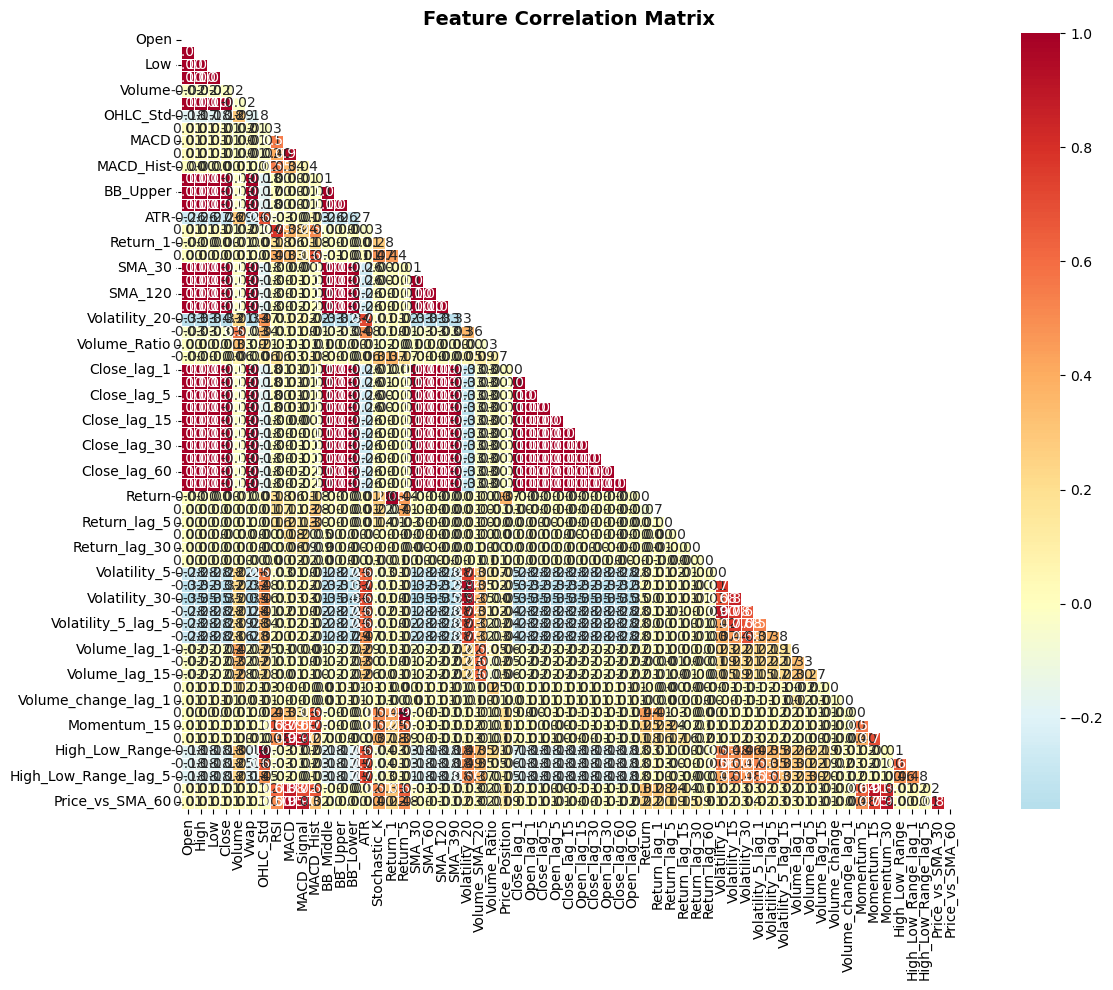

In [12]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlBu_r', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# REMOVE HIGHLY CORRELATED FEATURES
# =============================================================================

def remove_highly_correlated(dataframe: pd.DataFrame, threshold: float = 0.65, protect_cols: list = None) -> pd.DataFrame:
    """Remove features that are highly correlated with each other
    
    Args:
        dataframe: Input DataFrame
        threshold: Correlation threshold above which to remove features
        protect_cols: List of columns to never drop (e.g., target variable)
    """
    if protect_cols is None:
        protect_cols = []
    
    corr_matrix = dataframe.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find columns with correlation greater than threshold
    to_drop = set()
    for column in upper.columns:
        correlated = upper.index[upper[column] > threshold].tolist()
        if correlated:
            to_drop.update(correlated)
    
    # Remove protected columns from the drop list
    to_drop = to_drop - set(protect_cols)
    
    return dataframe.drop(columns=list(to_drop)), list(to_drop)

print("=" * 60)
print(f"REMOVING HIGHLY CORRELATED FEATURES (threshold = 0.65)")
print("=" * 60)

print(f"\nColumns BEFORE removal: {len(df.columns)}")
print(f"   {list(df.columns)}")

# Protect 'Close' from being dropped (it's our target variable)
df_reduced, dropped_cols = remove_highly_correlated(df, threshold=0.65, protect_cols=['Close'])

print(f"\n🗑️ Columns to remove (|r| > 0.65):")
for col in sorted(dropped_cols):
    print(f"   - {col}")

print(f"\n✅ Columns AFTER removal: {len(df_reduced.columns)}")
print(f"   {list(df_reduced.columns)}")

# Update df to the reduced version
df = df_reduced.copy()

print("\n" + "=" * 60)
print("UPDATED CORRELATION MATRIX (remaining features)")
print("=" * 60)
print(df.corr().round(2))

REMOVING HIGHLY CORRELATED FEATURES (threshold = 0.65)

Columns BEFORE removal: 61
   ['Open', 'High', 'Low', 'Close', 'Volume', 'Vwap', 'OHLC_Std', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'ATR', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_30', 'SMA_60', 'SMA_120', 'SMA_390', 'Volatility_20', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position', 'Close_lag_1', 'Open_lag_1', 'Close_lag_5', 'Open_lag_5', 'Close_lag_15', 'Open_lag_15', 'Close_lag_30', 'Open_lag_30', 'Close_lag_60', 'Open_lag_60', 'Return', 'Return_lag_1', 'Return_lag_5', 'Return_lag_15', 'Return_lag_30', 'Return_lag_60', 'Volatility_5', 'Volatility_15', 'Volatility_30', 'Volatility_5_lag_1', 'Volatility_5_lag_5', 'Volatility_5_lag_15', 'Volume_lag_1', 'Volume_lag_5', 'Volume_lag_15', 'Volume_change', 'Volume_change_lag_1', 'Momentum_5', 'Momentum_15', 'Momentum_30', 'High_Low_Range', 'High_Low_Range_lag_1', 'High_Low_Range_lag_5', 'Price_vs_SMA_30', 'Price_vs_SMA_60']



🗑️ Columns to remove (|r| > 0.65):
   - ATR
   - BB_Lower
   - BB_Middle
   - BB_Upper
   - Close_lag_1
   - Close_lag_15
   - Close_lag_30
   - Close_lag_5
   - Close_lag_60
   - High
   - Low
   - MACD
   - MACD_Hist
   - MACD_Signal
   - Momentum_15
   - Momentum_30
   - OHLC_Std
   - Open
   - Open_lag_1
   - Open_lag_15
   - Open_lag_30
   - Open_lag_5
   - Price_vs_SMA_30
   - RSI
   - Return_1
   - Return_5
   - SMA_120
   - SMA_30
   - SMA_390
   - SMA_60
   - Volatility_15
   - Volatility_20
   - Volatility_30
   - Volatility_5
   - Vwap

✅ Columns AFTER removal: 26
   ['Close', 'Volume', 'Stochastic_K', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position', 'Open_lag_60', 'Return', 'Return_lag_1', 'Return_lag_5', 'Return_lag_15', 'Return_lag_30', 'Return_lag_60', 'Volatility_5_lag_1', 'Volatility_5_lag_5', 'Volatility_5_lag_15', 'Volume_lag_1', 'Volume_lag_5', 'Volume_lag_15', 'Volume_change', 'Volume_change_lag_1', 'Momentum_5', 'High_Low_Range', 'High_Low_Range_lag_1', 'High_L

In [14]:
# =============================================================================
# PREPARE FINAL DATASET WITH TARGET VARIABLE
# =============================================================================

# IMPORTANT: We need to preserve 'Close' as our target before feature reduction
# Get the Close column from the original cleaned data before correlation removal
# We'll use df_reduced (features without highly correlated ones) + Close from before

# First, let's rebuild df_model with the reduced features PLUS the Close column
# The Close column should come from the data BEFORE the correlation removal step

# Check what we have available
print("=" * 60)
print("BUILDING FINAL MODELING DATASET")
print("=" * 60)

# df_reduced has the non-correlated features but may not have Close
# We need to get Close from before the dropna/cleaning step

# Re-read the original df data (this requires re-running earlier cells)
# For now, let's work with what we have in the kernel

# Check if Close exists in df or df_reduced
print(f"\n📋 Available DataFrames:")
print(f"   df columns: {list(df.columns)}")
print(f"   df shape: {df.shape}")
print(f"   df_reduced columns: {list(df_reduced.columns)}")
print(f"   df_reduced shape: {df_reduced.shape}")

# If Close is not in df, we have a problem - need to re-run from feature engineering
if 'Close' not in df.columns and 'Close' not in df_reduced.columns:
    print("\n⚠️ 'Close' column is missing!")
    print("   Please re-run cells from Feature Engineering (cell 8) onwards")
    print("   This will rebuild the data pipeline with Close preserved")
else:
    # Build the modeling dataframe
    if 'Close' in df_reduced.columns:
        df_model = df_reduced.copy()
    else:
        # Get Close from df and merge with df_reduced
        df_model = df_reduced.copy()
        df_model['Close'] = df['Close']
    
    print(f"\n✅ df_model created:")
    print(f"   Shape: {df_model.shape}")
    print(f"   Columns: {list(df_model.columns)}")

BUILDING FINAL MODELING DATASET

📋 Available DataFrames:
   df columns: ['Close', 'Volume', 'Stochastic_K', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position', 'Open_lag_60', 'Return', 'Return_lag_1', 'Return_lag_5', 'Return_lag_15', 'Return_lag_30', 'Return_lag_60', 'Volatility_5_lag_1', 'Volatility_5_lag_5', 'Volatility_5_lag_15', 'Volume_lag_1', 'Volume_lag_5', 'Volume_lag_15', 'Volume_change', 'Volume_change_lag_1', 'Momentum_5', 'High_Low_Range', 'High_Low_Range_lag_1', 'High_Low_Range_lag_5', 'Price_vs_SMA_60']
   df shape: (214198, 26)
   df_reduced columns: ['Close', 'Volume', 'Stochastic_K', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position', 'Open_lag_60', 'Return', 'Return_lag_1', 'Return_lag_5', 'Return_lag_15', 'Return_lag_30', 'Return_lag_60', 'Volatility_5_lag_1', 'Volatility_5_lag_5', 'Volatility_5_lag_15', 'Volume_lag_1', 'Volume_lag_5', 'Volume_lag_15', 'Volume_change', 'Volume_change_lag_1', 'Momentum_5', 'High_Low_Range', 'High_Low_Range_lag_1', 'High_Low_Range_lag_5'

In [15]:
# Display final dataframe
df

,Close,Volume,Stochastic_K,Volume_SMA_20,Volume_Ratio,Price_Position,Open_lag_60,Return,Return_lag_1,Return_lag_5,...,Volume_lag_1,Volume_lag_5,Volume_lag_15,Volume_change,Volume_change_lag_1,Momentum_5,High_Low_Range,High_Low_Range_lag_1,High_Low_Range_lag_5,Price_vs_SMA_60
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-10 14:59:00,563.9400,178235.000000,39.111111,234610.250000,0.759707,0.666667,567.8900,0.000408,0.000515,-0.000372,...,188513.000000,455367.000000,113136.000000,-0.054521,0.092633,0.3500,0.4200,0.4967,0.5000,-0.002419
2025-03-10 15:00:00,564.3000,495851.000000,55.111111,253977.150000,1.952345,0.506849,567.3200,0.000638,0.000408,-0.000444,...,178235.000000,221788.000000,157442.000000,1.782007,-0.054521,0.9600,0.7300,0.4200,0.4620,-0.001699
2025-03-10 15:01:00,564.8000,540050.000000,77.333333,276830.000000,1.950836,0.698795,567.1000,0.000886,0.000638,0.000124,...,495851.000000,956786.000000,188262.000000,0.089138,1.782007,1.3900,0.8300,0.7300,0.4600,-0.000771
2025-03-10 15:02:00,565.0400,248102.000000,90.000000,282288.450000,0.878895,0.914852,566.3200,0.000425,0.000886,0.000018,...,540050.000000,172531.000000,215199.000000,-0.540594,0.089138,1.6200,0.8221,0.8300,0.3750,-0.000311
2025-03-10 15:03:00,564.9500,195587.000000,91.304348,281880.000000,0.693866,0.526316,566.2300,-0.000159,0.000425,0.000515,...,248102.000000,188513.000000,282258.000000,-0.211667,-0.540594,1.2400,0.3800,0.8221,0.4967,-0.000436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-05 00:55:00,686.9365,988.050159,16.485162,1471.710837,0.671362,1.000000,686.2900,0.000155,-0.000291,-0.000030,...,5668.382998,3277.521428,345.699016,-0.825691,2.490111,-0.2635,0.0265,0.2046,0.0561,-0.000040
2026-03-05 00:56:00,686.8800,1530.028386,8.793901,1530.983288,0.999376,0.000000,686.2900,-0.000082,0.000155,0.000058,...,988.050159,286.217375,212.275736,0.548533,-0.825691,-0.3600,0.0200,0.0265,0.0300,-0.000139
2026-03-05 00:57:00,686.9800,3802.777733,28.156004,1690.553671,2.249427,0.666667,686.1800,0.000146,-0.000082,-0.000217,...,1530.028386,1078.322505,996.177906,1.485430,0.548533,-0.1111,0.0600,0.0200,0.0400,-0.000013


# Training

In [16]:
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_lightning import Trainer


c:\Users\batzi\anaconda3\envs\trading_brains\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Model Training

With limited data (87 rows), we'll use models that work well with small datasets:
1. **Ridge Regression** - baseline linear model with regularization
2. **Random Forest** - ensemble method, handles non-linearity
3. **XGBoost** - gradient boosting, often best for tabular data

We'll use walk-forward validation (time series split) to avoid data leakage.

In [17]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("DATA PREPARATION FOR MODELING")
print("=" * 60)

# Use df_model which should have features + Close
if 'df_model' not in dir() or df_model.shape[0] == 0:
    print("⚠️ df_model not found or empty. Attempting to rebuild...")
    # Fallback: try to use df if it has Close
    if 'Close' in df.columns and df.shape[0] > 0:
        df_model = df.copy()
        print(f"   Using df with {len(df_model)} rows")
    else:
        print("❌ ERROR: No valid data available!")
        print("   Please re-run cells from Feature Engineering onwards")
        raise ValueError("No data available for modeling")

# Ensure no NaN values
nan_count = df_model.isnull().sum().sum()
print(f"\n🔍 NaN values in df_model: {nan_count}")

if nan_count > 0:
    print(f"   Dropping {df_model.isnull().any(axis=1).sum()} rows with NaN values...")
    df_model = df_model.dropna()
    print(f"   Remaining rows: {len(df_model)}")

# Check for infinite values in numeric columns only
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
inf_mask = np.isinf(df_model[numeric_cols]).any(axis=1)
if inf_mask.sum() > 0:
    print(f"   Dropping {inf_mask.sum()} rows with infinite values...")
    df_model = df_model[~inf_mask]

# Define features and target
feature_columns = [col for col in df_model.columns if col != 'Close']
X = df_model[feature_columns].astype(np.float64).values
y = df_model['Close'].astype(np.float64).values

# Final check
print(f"\n✅ Data ready for modeling:")
print(f"   Features: {feature_columns}")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

if X.shape[0] == 0:
    raise ValueError("No samples available for training! Please re-run from Feature Engineering.")

# Time Series Cross-Validation setup
n_splits = min(5, X.shape[0] // 10)  # Ensure we have enough samples per split
n_splits = max(2, n_splits)  # At least 2 splits
tscv = TimeSeriesSplit(n_splits=n_splits)

print(f"\n📊 Time Series Cross-Validation:")
print(f"   Number of splits: {n_splits}")

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"   Split {i+1}: Train size={len(train_idx)}, Test size={len(test_idx)}")

DATA PREPARATION FOR MODELING

🔍 NaN values in df_model: 0

✅ Data ready for modeling:
   Features: ['Volume', 'Stochastic_K', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position', 'Open_lag_60', 'Return', 'Return_lag_1', 'Return_lag_5', 'Return_lag_15', 'Return_lag_30', 'Return_lag_60', 'Volatility_5_lag_1', 'Volatility_5_lag_5', 'Volatility_5_lag_15', 'Volume_lag_1', 'Volume_lag_5', 'Volume_lag_15', 'Volume_change', 'Volume_change_lag_1', 'Momentum_5', 'High_Low_Range', 'High_Low_Range_lag_1', 'High_Low_Range_lag_5', 'Price_vs_SMA_60']
   X shape: (214198, 25)
   y shape: (214198,)

📊 Time Series Cross-Validation:
   Number of splits: 5
   Split 1: Train size=35703, Test size=35699
   Split 2: Train size=71402, Test size=35699
   Split 3: Train size=107101, Test size=35699
   Split 4: Train size=142800, Test size=35699
   Split 5: Train size=178499, Test size=35699


In [18]:
# =============================================================================
# MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION
# =============================================================================
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost, fall back to GradientBoosting if not available
try:
    from xgboost import XGBRegressor
    use_xgboost = True
except ImportError:
    print("⚠️ XGBoost not installed, using sklearn's GradientBoostingRegressor instead")
    use_xgboost = False

# Define models to compare
if use_xgboost:
    models = {
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)
    }
else:
    models = {
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
    }

# Store results
results = {name: {'rmse': [], 'mae': [], 'r2': []} for name in models.keys()}

print("=" * 60)
print("MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION")
print("=" * 60)

# Scaler for features
scaler = StandardScaler()

for name, model in models.items():
    print(f"\n🔄 Training: {name}")
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale features
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name]['rmse'].append(rmse)
        results[name]['mae'].append(mae)
        results[name]['r2'].append(r2)
    
    avg_rmse = np.mean(results[name]['rmse'])
    avg_mae = np.mean(results[name]['mae'])
    avg_r2 = np.mean(results[name]['r2'])
    
    print(f"   Avg RMSE: ${avg_rmse:.4f}")
    print(f"   Avg MAE:  ${avg_mae:.4f}")
    print(f"   Avg R²:   {avg_r2:.4f}")

# Summary comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

summary_data = []
for name in models.keys():
    summary_data.append({
        'Model': name,
        'Avg RMSE': np.mean(results[name]['rmse']),
        'Std RMSE': np.std(results[name]['rmse']),
        'Avg MAE': np.mean(results[name]['mae']),
        'Avg R²': np.mean(results[name]['r2'])
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Best model
best_model_name = summary_df.loc[summary_df['Avg RMSE'].idxmin(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")

MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION

🔄 Training: Ridge Regression
   Avg RMSE: $0.7156
   Avg MAE:  $0.4601
   Avg R²:   0.9912

🔄 Training: Random Forest
   Avg RMSE: $12.4695
   Avg MAE:  $10.7063
   Avg R²:   -1.2063

🔄 Training: XGBoost
   Avg RMSE: $12.5557
   Avg MAE:  $10.8050
   Avg R²:   -1.2532

MODEL COMPARISON SUMMARY
           Model  Avg RMSE  Std RMSE   Avg MAE    Avg R²
Ridge Regression  0.715577  0.090635  0.460059  0.991220
   Random Forest 12.469545  9.554828 10.706338 -1.206264
         XGBoost 12.555720  9.663972 10.804989 -1.253176

🏆 Best Model: Ridge Regression


FINAL MODEL EVALUATION (Ridge Regression)

📊 Holdout Set Performance (last 1440 minutes):
   RMSE: $0.9016
   MAE:  $0.6254
   R²:   0.9163


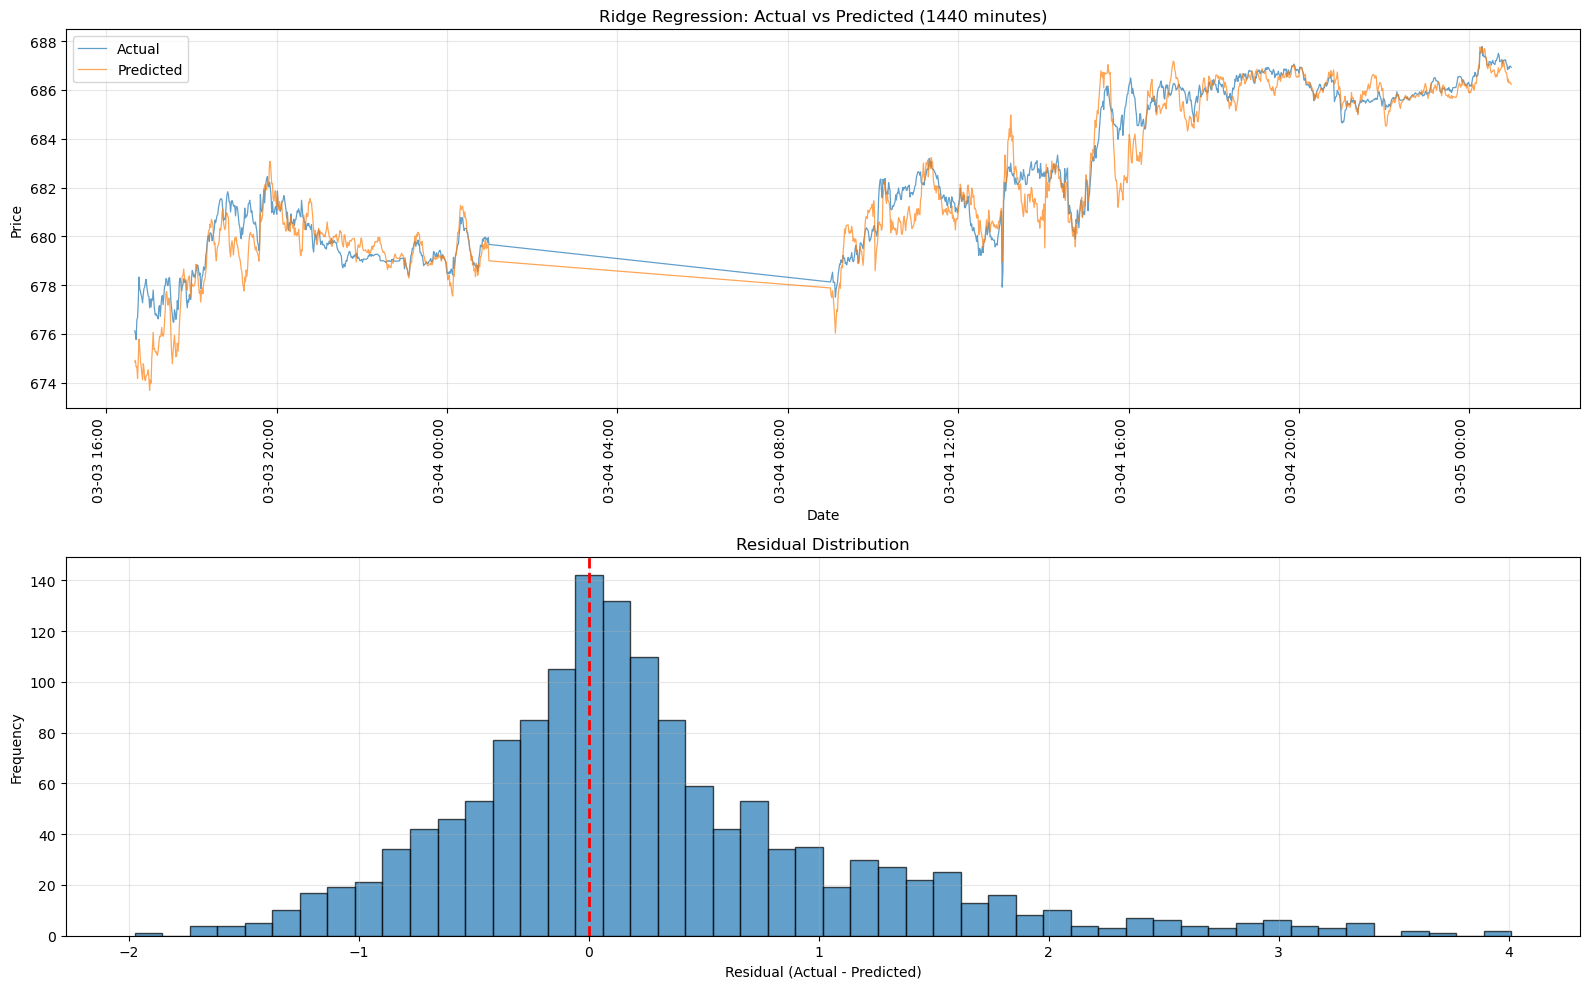


📊 Feature Coefficients (Ridge):
             Feature  Coefficient
         Open_lag_60    51.586206
     Price_vs_SMA_60     1.686512
          Momentum_5    -0.235510
       Return_lag_60     0.169331
        Return_lag_5    -0.101746
        Stochastic_K    -0.056106
       Return_lag_15    -0.049997
       Return_lag_30     0.036801
              Return    -0.031956
  Volatility_5_lag_1    -0.026732
      Price_Position     0.025573
      High_Low_Range    -0.023163
  Volatility_5_lag_5    -0.019216
        Return_lag_1    -0.017759
       Volume_SMA_20    -0.010176
High_Low_Range_lag_1    -0.009843
              Volume    -0.008787
        Volume_lag_1    -0.007286
        Volume_Ratio     0.007037
       Volume_lag_15     0.006675
High_Low_Range_lag_5    -0.004986
 Volatility_5_lag_15    -0.003713
        Volume_lag_5    -0.002873
 Volume_change_lag_1     0.000940
       Volume_change    -0.000391


In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

holdout_size = 1440

X_train_final = X[:-holdout_size]
X_test_final = X[-holdout_size:]
y_train_final = y[:-holdout_size]
y_test_final = y[-holdout_size:]

# Get the dates for the test set
test_dates = df_model.index[-holdout_size:]

# Scale
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Train best model (based on results)
if best_model_name == 'Ridge Regression':
    best_model = Ridge(alpha=1.0)
elif best_model_name == 'Random Forest':
    best_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
elif best_model_name == 'XGBoost' and use_xgboost:
    from xgboost import XGBRegressor
    best_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)
else:
    best_model = GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

best_model.fit(X_train_scaled, y_train_final)
y_pred_final = best_model.predict(X_test_scaled)

results_df = pd.DataFrame({
    'timestamp': test_dates,
    'actual': y_test_final.values if hasattr(y_test_final, 'values') else y_test_final,
    'predicted': y_pred_final
})

# Final metrics
final_rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
final_mae = mean_absolute_error(y_test_final, y_pred_final)
final_r2 = r2_score(y_test_final, y_pred_final)

print("=" * 60)
print(f"FINAL MODEL EVALUATION ({best_model_name})")
print("=" * 60)
print(f"\n📊 Holdout Set Performance (last {holdout_size} minutes):")
print(f"   RMSE: ${final_rmse:.4f}")
print(f"   MAE:  ${final_mae:.4f}")
print(f"   R²:   {final_r2:.4f}")

# Visualization - stacked vertically for better readability with large holdout
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Actual vs Predicted with dates on x-axis
axes[0].plot(test_dates, y_test_final, label='Actual', alpha=0.7, linewidth=0.9)
axes[0].plot(test_dates, y_pred_final, label='Predicted', alpha=0.7, linewidth=0.9)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted ({holdout_size} minutes)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Format x-axis dates
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[0].xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=90, ha='right')

# Plot 2: Residuals
residuals = y_test_final - y_pred_final
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    print("\n📊 Feature Importance:")
    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(importance_df.to_string(index=False))
elif hasattr(best_model, 'coef_'):
    print("\n📊 Feature Coefficients (Ridge):")
    coef_df = pd.DataFrame({
        'Feature': feature_columns,
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    print(coef_df.to_string(index=False))

In [24]:
results_df

,timestamp,actual,predicted
0,2026-03-03 16:40:00,676.1300,674.857988
1,2026-03-03 16:41:00,676.0000,674.921685
2,2026-03-03 16:42:00,675.7700,674.647959
3,2026-03-03 16:43:00,676.5700,674.663252
4,2026-03-03 16:44:00,676.6800,674.181949
...,...,...,...
1435,2026-03-05 00:55:00,686.9365,686.445056
1436,2026-03-05 00:56:00,686.8800,686.280191
1437,2026-03-05 00:57:00,686.9800,686.316853
1438,2026-03-05 00:58:00,686.9700,686.303050


In [25]:
results_df.to_csv(r'C:\Users\batzi\OneDrive\Dokumente\trading_brains\test_actual_vs_predicted.csv', index=False)

# Multi-Horizon Price Prediction

Extending our model to predict closing prices for larger timeframes (5, 15, 30, 60 minutes ahead).

In [26]:
# =============================================================================
# 1. MODIFY TARGET VARIABLE - Multi-Horizon Targets
# =============================================================================

def create_multi_horizon_targets(data, horizons=[5, 15, 30, 60]):
    """
    Create target variables for multiple prediction horizons.
    
    Parameters:
    -----------
    data : DataFrame
        DataFrame with 'close' column (OHLCV data)
    horizons : list
        List of prediction horizons in minutes
        
    Returns:
    --------
    DataFrame with additional target columns
    """
    df_targets = data.copy()
    
    for h in horizons:
        # Absolute price target
        df_targets[f'target_close_{h}min'] = df_targets['close'].shift(-h)
        
        # Return-based target (often better for ML)
        df_targets[f'target_return_{h}min'] = (
            df_targets['close'].shift(-h) - df_targets['close']
        ) / df_targets['close'] * 100  # Percentage return
        
        # Direction target (for classification)
        df_targets[f'target_direction_{h}min'] = (
            df_targets['close'].shift(-h) > df_targets['close']
        ).astype(int)
    
    return df_targets

# Apply to our data
df_multi_horizon = create_multi_horizon_targets(df)

# Display the new target columns
target_cols = [col for col in df_multi_horizon.columns if 'target_' in col]
print(f"Created {len(target_cols)} new target columns:")
print(target_cols)
print(f"\nSample of multi-horizon targets:")
df_multi_horizon[['close'] + target_cols[:8]].tail(10)

KeyError: 'close'

In [ ]:
# =============================================================================
# 2. AGGREGATE FEATURES FROM MULTIPLE TIMEFRAMES
# =============================================================================

def create_multiscale_features(data, windows=[5, 15, 30, 60, 120]):
    """
    Create features at multiple time scales for longer-horizon predictions.
    
    Parameters:
    -----------
    data : DataFrame
        OHLCV DataFrame
    windows : list
        List of rolling window sizes in minutes
        
    Returns:
    --------
    DataFrame with multi-scale features
    """
    df_features = data.copy()
    
    for window in windows:
        # Price-based features
        df_features[f'sma_{window}'] = df_features['close'].rolling(window).mean()
        df_features[f'ema_{window}'] = df_features['close'].ewm(span=window).mean()
        df_features[f'std_{window}'] = df_features['close'].rolling(window).std()
        
        # Price relative to moving average
        df_features[f'close_vs_sma_{window}'] = (
            df_features['close'] / df_features[f'sma_{window}'] - 1
        ) * 100
        
        # Momentum / Returns over window
        df_features[f'return_{window}'] = df_features['close'].pct_change(window) * 100
        
        # Volatility features
        df_features[f'high_low_range_{window}'] = (
            df_features['high'].rolling(window).max() - 
            df_features['low'].rolling(window).min()
        )
        df_features[f'atr_{window}'] = (
            df_features['high'].rolling(window).max() - 
            df_features['low'].rolling(window).min()
        ) / df_features['close'] * 100  # Normalized ATR
        
        # Volume features
        df_features[f'volume_ma_{window}'] = df_features['volume'].rolling(window).mean()
        df_features[f'volume_ratio_{window}'] = (
            df_features['volume'] / df_features[f'volume_ma_{window}']
        )
        
        # RSI approximation
        delta = df_features['close'].diff()
        gain = delta.where(delta > 0, 0).rolling(window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
        rs = gain / (loss + 1e-10)
        df_features[f'rsi_{window}'] = 100 - (100 / (1 + rs))
        
        # Bollinger Band position
        upper_band = df_features[f'sma_{window}'] + 2 * df_features[f'std_{window}']
        lower_band = df_features[f'sma_{window}'] - 2 * df_features[f'std_{window}']
        df_features[f'bb_position_{window}'] = (
            (df_features['close'] - lower_band) / (upper_band - lower_band + 1e-10)
        )
    
    return df_features

# Apply multi-scale features
df_multiscale = create_multiscale_features(df_multi_horizon)

# Show new feature count
new_feature_cols = [col for col in df_multiscale.columns 
                    if any(str(w) in col for w in [5, 15, 30, 60, 120])
                    and 'target_' not in col]
print(f"Created {len(new_feature_cols)} multi-scale features")
print(f"\nFeature groups per window:")
for window in [5, 15, 30, 60, 120]:
    cols = [col for col in new_feature_cols if f'_{window}' in col]
    print(f"  {window}-min window: {len(cols)} features")

print(f"\nDataFrame shape: {df_multiscale.shape}")

In [ ]:
# =============================================================================
# 3. RESAMPLE OHLCV TO LARGER TIMEFRAMES
# =============================================================================

def resample_ohlcv(data, timeframe='60T'):
    """
    Resample minute OHLCV data to larger timeframes.
    
    Parameters:
    -----------
    data : DataFrame
        OHLCV DataFrame with DatetimeIndex
    timeframe : str
        Target timeframe (e.g., '5T', '15T', '30T', '60T', '1D')
        
    Returns:
    --------
    Resampled OHLCV DataFrame
    """
    # Ensure datetime index
    df_resample = data.copy()
    if not isinstance(df_resample.index, pd.DatetimeIndex):
        if 'timestamp' in df_resample.columns:
            df_resample.set_index('timestamp', inplace=True)
        elif 'date' in df_resample.columns:
            df_resample.set_index('date', inplace=True)
    
    # Standard OHLCV aggregation rules
    ohlcv_dict = {
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }
    
    # Only aggregate columns that exist
    agg_dict = {k: v for k, v in ohlcv_dict.items() if k in df_resample.columns}
    
    resampled = df_resample.resample(timeframe).agg(agg_dict).dropna()
    
    return resampled

# Create different timeframe datasets
print("Resampling to different timeframes...\n")

timeframes = {
    '5T': '5-minute bars',
    '15T': '15-minute bars', 
    '30T': '30-minute bars',
    '60T': '60-minute (hourly) bars',
    '1D': 'Daily bars'
}

resampled_data = {}
for tf, desc in timeframes.items():
    resampled_data[tf] = resample_ohlcv(df, tf)
    print(f"{desc}: {len(resampled_data[tf])} bars")

# Show sample of hourly data
print("\n--- Sample of Hourly (60T) Resampled Data ---")
resampled_data['60T'].tail(10)

## Multi-Output Model

Train a single model that predicts multiple horizons simultaneously. This can capture relationships between different forecast horizons.

In [ ]:
# =============================================================================
# 4. MULTI-OUTPUT MODEL - Predict Multiple Horizons Simultaneously
# =============================================================================

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

def prepare_multi_output_data(data, horizons=[5, 15, 30, 60]):
    """
    Prepare data for multi-output regression.
    """
    df_prep = data.copy()
    
    # Define target columns (using returns for better scaling)
    target_cols = [f'target_return_{h}min' for h in horizons]
    
    # Check which target columns exist
    available_targets = [col for col in target_cols if col in df_prep.columns]
    
    if not available_targets:
        raise ValueError("No target columns found. Run create_multi_horizon_targets first.")
    
    # Define feature columns (exclude targets and raw OHLCV)
    exclude_patterns = ['target_', 'open', 'high', 'low', 'close', 'volume']
    feature_cols = [col for col in df_prep.columns 
                    if not any(pattern in col for pattern in exclude_patterns)]
    
    # If no features found, use all numeric columns except targets
    if not feature_cols:
        feature_cols = [col for col in df_prep.select_dtypes(include=[np.number]).columns
                       if 'target_' not in col]
    
    # Drop NaN rows
    df_clean = df_prep.dropna(subset=available_targets + feature_cols)
    
    X = df_clean[feature_cols].values
    y = df_clean[available_targets].values
    
    return X, y, feature_cols, available_targets

# Prepare data
print("Preparing multi-output data...")
X_multi, y_multi, feature_names, target_names = prepare_multi_output_data(df_multiscale)

print(f"Features: {len(feature_names)}")
print(f"Targets: {target_names}")
print(f"Samples: {len(X_multi)}")

# Train/test split (time-based)
split_idx = int(len(X_multi) * 0.8)
X_train_mo, X_test_mo = X_multi[:split_idx], X_multi[split_idx:]
y_train_mo, y_test_mo = y_multi[:split_idx], y_multi[split_idx:]

print(f"\nTrain samples: {len(X_train_mo)}")
print(f"Test samples: {len(X_test_mo)}")

In [ ]:
# Train Multi-Output Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Scale features
scaler_mo = StandardScaler()
X_train_mo_scaled = scaler_mo.fit_transform(X_train_mo)
X_test_mo_scaled = scaler_mo.transform(X_test_mo)

# Train multi-output model
print("Training Multi-Output GradientBoosting model...")
print("(This may take a few minutes)\n")

multi_model = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
    n_jobs=-1  # Parallelize across outputs
)

multi_model.fit(X_train_mo_scaled, y_train_mo)

# Predictions
y_pred_mo = multi_model.predict(X_test_mo_scaled)

# Evaluate each horizon
print("=" * 60)
print("Multi-Output Model Results by Horizon")
print("=" * 60)

results_mo = {}
for i, target in enumerate(target_names):
    horizon = target.replace('target_return_', '').replace('min', '')
    rmse = np.sqrt(mean_squared_error(y_test_mo[:, i], y_pred_mo[:, i]))
    mae = mean_absolute_error(y_test_mo[:, i], y_pred_mo[:, i])
    r2 = r2_score(y_test_mo[:, i], y_pred_mo[:, i])
    
    # Directional accuracy
    actual_direction = (y_test_mo[:, i] > 0).astype(int)
    pred_direction = (y_pred_mo[:, i] > 0).astype(int)
    dir_accuracy = (actual_direction == pred_direction).mean() * 100
    
    results_mo[horizon] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Direction_Accuracy': dir_accuracy
    }
    
    print(f"\n{horizon}-minute Horizon:")
    print(f"  RMSE: {rmse:.4f}%")
    print(f"  MAE:  {mae:.4f}%")
    print(f"  R²:   {r2:.4f}")
    print(f"  Directional Accuracy: {dir_accuracy:.1f}%")

# Summary DataFrame
results_mo_df = pd.DataFrame(results_mo).T
results_mo_df.index.name = 'Horizon (min)'
print("\n" + "=" * 60)
print("Summary Table:")
results_mo_df

In [ ]:
# Visualize Multi-Output Model Performance
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

horizons_list = list(results_mo.keys())

# Plot 1: RMSE by horizon
ax1 = axes[0, 0]
rmse_values = [results_mo[h]['RMSE'] for h in horizons_list]
ax1.bar(horizons_list, rmse_values, color='steelblue', alpha=0.8)
ax1.set_xlabel('Forecast Horizon (minutes)')
ax1.set_ylabel('RMSE (%)')
ax1.set_title('RMSE by Forecast Horizon')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: R² by horizon
ax2 = axes[0, 1]
r2_values = [results_mo[h]['R2'] for h in horizons_list]
colors = ['green' if r > 0 else 'red' for r in r2_values]
ax2.bar(horizons_list, r2_values, color=colors, alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Forecast Horizon (minutes)')
ax2.set_ylabel('R² Score')
ax2.set_title('R² Score by Forecast Horizon')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Directional Accuracy by horizon
ax3 = axes[1, 0]
dir_values = [results_mo[h]['Direction_Accuracy'] for h in horizons_list]
ax3.bar(horizons_list, dir_values, color='orange', alpha=0.8)
ax3.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Random (50%)')
ax3.set_xlabel('Forecast Horizon (minutes)')
ax3.set_ylabel('Accuracy (%)')
ax3.set_title('Directional Accuracy by Horizon')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Actual vs Predicted for 60-min horizon
ax4 = axes[1, 1]
idx_60 = target_names.index('target_return_60min') if 'target_return_60min' in target_names else -1
if idx_60 >= 0:
    sample_size = min(200, len(y_test_mo))
    ax4.plot(y_test_mo[:sample_size, idx_60], label='Actual', alpha=0.7)
    ax4.plot(y_pred_mo[:sample_size, idx_60], label='Predicted', alpha=0.7)
    ax4.set_xlabel('Sample')
    ax4.set_ylabel('Return (%)')
    ax4.set_title('60-min Return: Actual vs Predicted')
    ax4.legend()
    ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Sequence Models (LSTM) for Long-Horizon Prediction

LSTM networks can capture temporal dependencies in sequential data, making them well-suited for longer forecast horizons where patterns over time matter.

In [ ]:
# =============================================================================
# 5. SEQUENCE MODEL (LSTM) FOR LONGER HORIZONS
# =============================================================================

# Check if TensorFlow is available
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    print(f"TensorFlow version: {tf.__version__}")
except ImportError:
    TF_AVAILABLE = False
    print("TensorFlow not installed. Install with: pip install tensorflow")
    print("Skipping LSTM model...")

In [ ]:
# Prepare sequence data for LSTM
def create_sequences(data, sequence_length=60, forecast_horizon=60):
    """
    Create sequences for LSTM input.
    
    Parameters:
    -----------
    data : DataFrame
        Input DataFrame with features
    sequence_length : int
        Number of time steps to look back
    forecast_horizon : int
        How many steps ahead to predict
        
    Returns:
    --------
    X : array of shape (samples, sequence_length, features)
    y : array of target values
    """
    # Select numeric features
    feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remove target columns from features
    feature_cols = [c for c in feature_cols if 'target_' not in c]
    
    # Target column
    target_col = f'target_return_{forecast_horizon}min'
    if target_col not in data.columns:
        # Fall back to computing it
        data = data.copy()
        data[target_col] = (data['close'].shift(-forecast_horizon) - data['close']) / data['close'] * 100
    
    # Drop NaN
    df_clean = data.dropna()
    
    # Extract values
    features = df_clean[feature_cols].values
    target = df_clean[target_col].values
    
    # Normalize features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    X, y = [], []
    for i in range(sequence_length, len(features_scaled) - forecast_horizon):
        X.append(features_scaled[i-sequence_length:i])
        y.append(target[i])
    
    return np.array(X), np.array(y), scaler, feature_cols

# Only run if TensorFlow is available
if TF_AVAILABLE:
    print("Creating sequences for LSTM...")
    SEQUENCE_LENGTH = 60  # Look back 60 minutes
    FORECAST_HORIZON = 60  # Predict 60 minutes ahead
    
    X_seq, y_seq, seq_scaler, seq_features = create_sequences(
        df_multiscale, 
        sequence_length=SEQUENCE_LENGTH,
        forecast_horizon=FORECAST_HORIZON
    )
    
    print(f"Sequence shape: {X_seq.shape}")
    print(f"Target shape: {y_seq.shape}")
    print(f"Features per timestep: {len(seq_features)}")
    
    # Time-based train/test split
    split_idx = int(len(X_seq) * 0.8)
    X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
    y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]
    
    print(f"\nTrain sequences: {len(X_train_seq)}")
    print(f"Test sequences: {len(X_test_seq)}")

In [ ]:
# Build and Train LSTM Model
if TF_AVAILABLE:
    def build_lstm_model(sequence_length, n_features, forecast_horizon=1):
        """
        Build LSTM model for time series forecasting.
        """
        model = Sequential([
            # First LSTM layer
            LSTM(128, return_sequences=True, 
                 input_shape=(sequence_length, n_features)),
            BatchNormalization(),
            Dropout(0.2),
            
            # Second LSTM layer
            LSTM(64, return_sequences=True),
            BatchNormalization(),
            Dropout(0.2),
            
            # Third LSTM layer
            LSTM(32, return_sequences=False),
            BatchNormalization(),
            Dropout(0.2),
            
            # Dense layers
            Dense(32, activation='relu'),
            Dropout(0.1),
            Dense(16, activation='relu'),
            
            # Output layer
            Dense(1)  # Single output for point prediction
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    # Build model
    n_features = X_train_seq.shape[2]
    lstm_model = build_lstm_model(SEQUENCE_LENGTH, n_features, FORECAST_HORIZON)
    
    print("LSTM Model Architecture:")
    lstm_model.summary()

In [ ]:
# Train LSTM Model
if TF_AVAILABLE:
    print("Training LSTM model...")
    print("=" * 60)
    
    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
    
    # Train
    history = lstm_model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.15,
        epochs=50,
        batch_size=64,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    print("\nTraining complete!")

In [ ]:
# Evaluate LSTM Model
if TF_AVAILABLE:
    # Predictions
    y_pred_lstm = lstm_model.predict(X_test_seq).flatten()
    
    # Metrics
    lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
    lstm_mae = mean_absolute_error(y_test_seq, y_pred_lstm)
    lstm_r2 = r2_score(y_test_seq, y_pred_lstm)
    
    # Directional accuracy
    actual_dir = (y_test_seq > 0).astype(int)
    pred_dir = (y_pred_lstm > 0).astype(int)
    lstm_dir_acc = (actual_dir == pred_dir).mean() * 100
    
    print("=" * 60)
    print(f"LSTM Model Results ({FORECAST_HORIZON}-minute Horizon)")
    print("=" * 60)
    print(f"RMSE: {lstm_rmse:.4f}%")
    print(f"MAE:  {lstm_mae:.4f}%")
    print(f"R²:   {lstm_r2:.4f}")
    print(f"Directional Accuracy: {lstm_dir_acc:.1f}%")
    
    # Compare with Multi-Output model
    if '60' in results_mo:
        print("\n" + "-" * 60)
        print("Comparison with Multi-Output GBM (60-min horizon):")
        print("-" * 60)
        print(f"{'Metric':<25} {'LSTM':<15} {'Multi-Output GBM':<15}")
        print("-" * 60)
        print(f"{'RMSE':<25} {lstm_rmse:<15.4f} {results_mo['60']['RMSE']:<15.4f}")
        print(f"{'MAE':<25} {lstm_mae:<15.4f} {results_mo['60']['MAE']:<15.4f}")
        print(f"{'R²':<25} {lstm_r2:<15.4f} {results_mo['60']['R2']:<15.4f}")
        print(f"{'Direction Acc.':<25} {lstm_dir_acc:<15.1f} {results_mo['60']['Direction_Accuracy']:<15.1f}")

In [ ]:
# Visualize LSTM Results
if TF_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Training history - Loss
    ax1 = axes[0, 0]
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('MSE Loss')
    ax1.set_title('LSTM Training History - Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot 2: Training history - MAE
    ax2 = axes[0, 1]
    ax2.plot(history.history['mae'], label='Training MAE')
    ax2.plot(history.history['val_mae'], label='Validation MAE')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.set_title('LSTM Training History - MAE')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: Actual vs Predicted
    ax3 = axes[1, 0]
    sample_size = min(300, len(y_test_seq))
    ax3.plot(y_test_seq[:sample_size], label='Actual', alpha=0.7)
    ax3.plot(y_pred_lstm[:sample_size], label='Predicted', alpha=0.7)
    ax3.set_xlabel('Sample')
    ax3.set_ylabel('Return (%)')
    ax3.set_title(f'{FORECAST_HORIZON}-min Return: Actual vs Predicted (LSTM)')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # Plot 4: Scatter plot Actual vs Predicted
    ax4 = axes[1, 1]
    ax4.scatter(y_test_seq, y_pred_lstm, alpha=0.3, s=10)
    ax4.plot([y_test_seq.min(), y_test_seq.max()], 
             [y_test_seq.min(), y_test_seq.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
    ax4.set_xlabel('Actual Return (%)')
    ax4.set_ylabel('Predicted Return (%)')
    ax4.set_title('LSTM: Actual vs Predicted Scatter')
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Summary: Multi-Horizon Price Prediction

| Approach | Best For | Key Points |
|----------|----------|------------|
| **Multi-Horizon Targets** | Quick experimentation | Simple shift of target variable |
| **Multi-Scale Features** | Capturing patterns at different frequencies | Rolling windows at 5, 15, 30, 60, 120 min |
| **OHLCV Resampling** | Training on aggregated data directly | Reduces noise, but also data points |
| **Multi-Output Model** | Predicting multiple horizons at once | Can share learned representations |
| **LSTM Sequence Model** | Capturing temporal patterns | Better for longer sequences, more compute |

### Next Steps
- Tune hyperparameters for best performing model
- Try attention mechanisms (Transformer) for very long horizons
- Combine features from multiple resampled timeframes
- Add exogenous features (sentiment, macro indicators)